# PREDICTING STUDENT DROPOUT AND ACADEMIC SUCCESS USING MACHINE LEARNING TECHNIQUES

## Load and Display Data

In [ ]:
import pandas as pd

df = pd.read_csv('/content/students_dropout_academic_success.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("\nColumn names and their data types:")
df.info()

print("\nDescriptive statistics for the dataset:")
print(df.describe())

First 5 rows of the dataset:
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2        

## Analyze Potential Target Variables


In [ ]:
print("Unique values and their counts for the 'target' column:")
print(df['target'].value_counts())


Unique values and their counts for the 'target' column:
target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## Data Overview and Summary

In [ ]:
print(f"The DataFrame has {df.shape[0]} rows and {df.shape[1]} columns.")

The DataFrame has 4424 rows and 37 columns.


In [ ]:
print("\nInformation about the DataFrame (data types, non-null values, memory usage):")
df.info()


Information about the DataFrame (data types, non-null values, memory usage):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                  

In [ ]:
print("\nDescriptive statistics for the dataset:")
print(df.describe())


Descriptive statistics for the dataset:
       Marital Status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime/evening attendance  Previous qualification  \
count                 4424.000000             4424.000000   
mean                     0.890823                4.577758   
std                      0.311897               10.216592   
min                      0.000000      

## Missing Values Analysis



In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if missing_info.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values in each column:")
    print(missing_info)


No missing values found in the dataset.


## Outlier Detection (Numerical Features)



In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Exclude columns identified as categorical or count/code-based, or the target column
# The target column is already excluded by dtypes, but good to be explicit if it was numerical
exclude_cols = [
    'Marital Status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment',
    'International',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)'
]

# Filter out the excluded columns
# Also explicitly exclude 'target' just in case, though it's an object type
numerical_for_outliers = [col for col in numerical_cols if col not in exclude_cols and col != 'target']

print("Numerical columns selected for outlier detection:")
print(numerical_for_outliers)


Numerical columns selected for outlier detection:
['Previous qualification (grade)', 'Admission grade', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [ ]:
print("Descriptive statistics for numerical columns selected for outlier detection:")
print(df[numerical_for_outliers].describe())

Descriptive statistics for numerical columns selected for outlier detection:
       Previous qualification (grade)  Admission grade  \
count                     4424.000000      4424.000000   
mean                       132.613314       126.978119   
std                         13.188332        14.482001   
min                         95.000000        95.000000   
25%                        125.000000       117.900000   
50%                        133.100000       126.100000   
75%                        140.000000       134.800000   
max                        190.000000       190.000000   

       Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)  \
count                       4424.000000                       4424.000000   
mean                          10.640822                         10.230206   
std                            4.843663                          5.210808   
min                            0.000000                          0.000000   
25%            

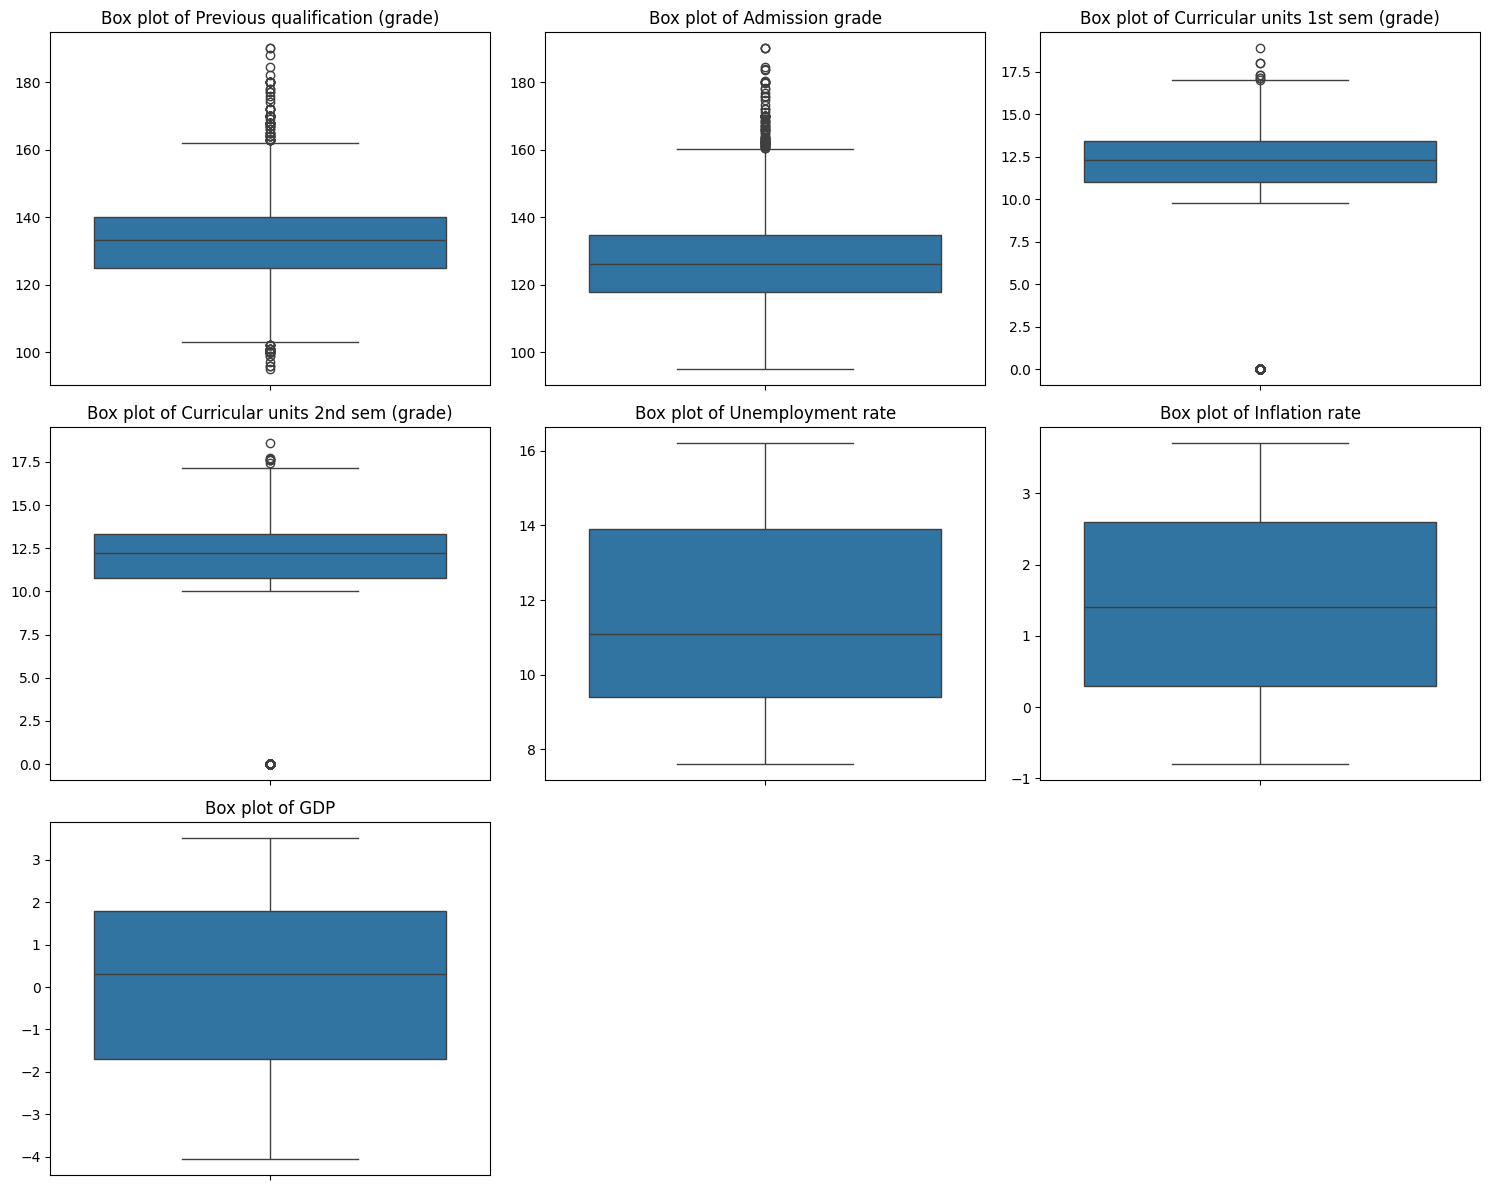

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine the number of rows and columns for the subplots
n_cols = 3  # For example, 3 columns per row
n_rows = (len(numerical_for_outliers) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numerical_for_outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()


## Data Dictionary Generation



In [ ]:
data_dictionary = {
    'Marital Status': {'data_type': 'int64', 'description': 'Categorical: Marital status of the student (e.g., single, married). Specific codes are not provided, but typically represent different statuses.'},
    'Application mode': {'data_type': 'int64', 'description': 'Categorical: Mode of application (e.g., 1st phase, 2nd phase). Specific codes are not provided, but each number represents a different application method.'},
    'Application order': {'data_type': 'int64', 'description': 'Ordinal: Order of application (e.g., 1st, 2nd, 3rd choice). Higher numbers indicate a lower preference for the course.'},
    'Course': {'data_type': 'int64', 'description': 'Categorical: Course code. Each number corresponds to a specific academic program.'},
    'Daytime/evening attendance': {'data_type': 'int64', 'description': 'Binary: 1 for daytime attendance, 0 for evening attendance.'},
    'Previous qualification': {'data_type': 'int64', 'description': 'Categorical: Previous academic qualification (e.g., high school, bachelor). Specific codes are not provided.'},
    'Previous qualification (grade)': {'data_type': 'float64', 'description': 'Numerical: Grade obtained in previous academic qualification.'},
    'Nacionality': {'data_type': 'int64', 'description': 'Categorical: Nationality of the student. Specific codes are not provided.'},
    "Mother's qualification": {'data_type': 'int64', 'description': 'Categorical: Qualification of the student\'s mother. Specific codes are not provided.'},
    "Father's qualification": {'data_type': 'int64', 'description': 'Categorical: Qualification of the student\'s father. Specific codes are not provided.'},
    "Mother's occupation": {'data_type': 'int64', 'description': 'Categorical: Occupation of the student\'s mother. Specific codes are not provided.'},
    "Father's occupation": {'data_type': 'int64', 'description': 'Categorical: Occupation of the student\'s father. Specific codes are not provided.'},
    'Admission grade': {'data_type': 'float64', 'description': 'Numerical: Grade obtained in the admission process.'},
    'Displaced': {'data_type': 'int64', 'description': 'Binary: Whether the student is displaced (1 if yes, 0 if no). This could refer to living away from home for studies.'},
    'Educational special needs': {'data_type': 'int64', 'description': 'Binary: Whether the student has special educational needs (1 if yes, 0 if no).'},
    'Debtor': {'data_type': 'int64', 'description': 'Binary: Whether the student is a debtor (1 if yes, 0 if no). Likely refers to outstanding tuition fees or other financial obligations.'},
    'Tuition fees up to date': {'data_type': 'int64', 'description': 'Binary: Whether the student has paid tuition fees up to date (1 if yes, 0 if no).'},
    'Gender': {'data_type': 'int64', 'description': 'Binary: Gender of the student (e.g., 1 for male, 0 for female or vice-versa). Specific mapping is unknown.'},
    'Scholarship holder': {'data_type': 'int64', 'description': 'Binary: Whether the student is a scholarship holder (1 if yes, 0 if no).'},
    'Age at enrollment': {'data_type': 'int64', 'description': 'Numerical: Age of the student at the time of enrollment.'},
    'International': {'data_type': 'int64', 'description': 'Binary: Whether the student is an international student (1 if yes, 0 if no).'},
    'Curricular units 1st sem (credited)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units credited in the 1st semester.'},
    'Curricular units 1st sem (enrolled)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units enrolled in the 1st semester.'},
    'Curricular units 1st sem (evaluations)': {'data_type': 'int64', 'description': 'Numerical: Number of evaluations performed in the 1st semester curricular units.'},
    'Curricular units 1st sem (approved)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units approved in the 1st semester.'},
    'Curricular units 1st sem (grade)': {'data_type': 'float64', 'description': 'Numerical: Average grade obtained in the 1st semester curricular units.'},
    'Curricular units 1st sem (without evaluations)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units in the 1st semester without evaluations.'},
    'Curricular units 2nd sem (credited)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units credited in the 2nd semester.'},
    'Curricular units 2nd sem (enrolled)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units enrolled in the 2nd semester.'},
    'Curricular units 2nd sem (evaluations)': {'data_type': 'int64', 'description': 'Numerical: Number of evaluations performed in the 2nd semester curricular units.'},
    'Curricular units 2nd sem (approved)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units approved in the 2nd semester.'},
    'Curricular units 2nd sem (grade)': {'data_type': 'float64', 'description': 'Numerical: Average grade obtained in the 2nd semester curricular units.'},
    'Curricular units 2nd sem (without evaluations)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units in the 2nd semester without evaluations.'},
    'Unemployment rate': {'data_type': 'float64', 'description': 'Numerical: Unemployment rate in the period of enrollment (contextual socio-economic factor).'},
    'Inflation rate': {'data_type': 'float64', 'description': 'Numerical: Inflation rate in the period of enrollment (contextual socio-economic factor).'},
    'GDP': {'data_type': 'float64', 'description': 'Numerical: Gross Domestic Product in the period of enrollment (contextual socio-economic factor).'},
    'target': {'data_type': 'object', 'description': 'Categorical: The academic outcome of the student. Possible values: \'Graduate\', \'Dropout\', \'Enrolled\'. This is the target variable for prediction.'}
}

print("### Data Dictionary")
for column, details in data_dictionary.items():
    print(f"\n- **{column}**:")
    print(f"  - Data Type: {details['data_type']}")
    print(f"  - Description: {details['description']}")


### Data Dictionary

- **Marital Status**:
  - Data Type: int64
  - Description: Categorical: Marital status of the student (e.g., single, married). Specific codes are not provided, but typically represent different statuses.

- **Application mode**:
  - Data Type: int64
  - Description: Categorical: Mode of application (e.g., 1st phase, 2nd phase). Specific codes are not provided, but each number represents a different application method.

- **Application order**:
  - Data Type: int64
  - Description: Ordinal: Order of application (e.g., 1st, 2nd, 3rd choice). Higher numbers indicate a lower preference for the course.

- **Course**:
  - Data Type: int64
  - Description: Categorical: Course code. Each number corresponds to a specific academic program.

- **Daytime/evening attendance**:
  - Data Type: int64
  - Description: Binary: 1 for daytime attendance, 0 for evening attendance.

- **Previous qualification**:
  - Data Type: int64
  - Description: Categorical: Previous academic quali

In [ ]:
data_dictionary_df = pd.DataFrame.from_dict(data_dictionary, orient='index')
data_dictionary_df.index.name = 'Feature'
display(data_dictionary_df)

,data_type,description
Feature,,
Marital Status,int64,Categorical: Marital status of the student (e....
Application mode,int64,"Categorical: Mode of application (e.g., 1st ph..."
Application order,int64,"Ordinal: Order of application (e.g., 1st, 2nd,..."
Course,int64,Categorical: Course code. Each number correspo...
Daytime/evening attendance,int64,"Binary: 1 for daytime attendance, 0 for evenin..."
Previous qualification,int64,Categorical: Previous academic qualification (...
Previous qualification (grade),float64,Numerical: Grade obtained in previous academic...
Nacionality,int64,Categorical: Nationality of the student. Speci...
Mother's qualification,int64,Categorical: Qualification of the student's mo...


## Identify Categorical Features


In [ ]:
object_cols = df.select_dtypes(include='object').columns.tolist()

# Identify int64 columns that are categorical codes
# Based on the data dictionary, these are the columns where unique values represent categories
# and are not continuous numbers like grades or counts of curricular units.
int_categorical_cols = [
    'Marital Status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

# Combine all identified categorical columns
categorical_features = int_categorical_cols

# Ensure 'target' is not in the list, though it's already excluded by explicit listing
if 'target' in categorical_features:
    categorical_features.remove('target')

print("Identified categorical features (excluding 'target'):")
print(categorical_features)

Identified categorical features (excluding 'target'):
['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']


## Generate Histograms for Numerical Features



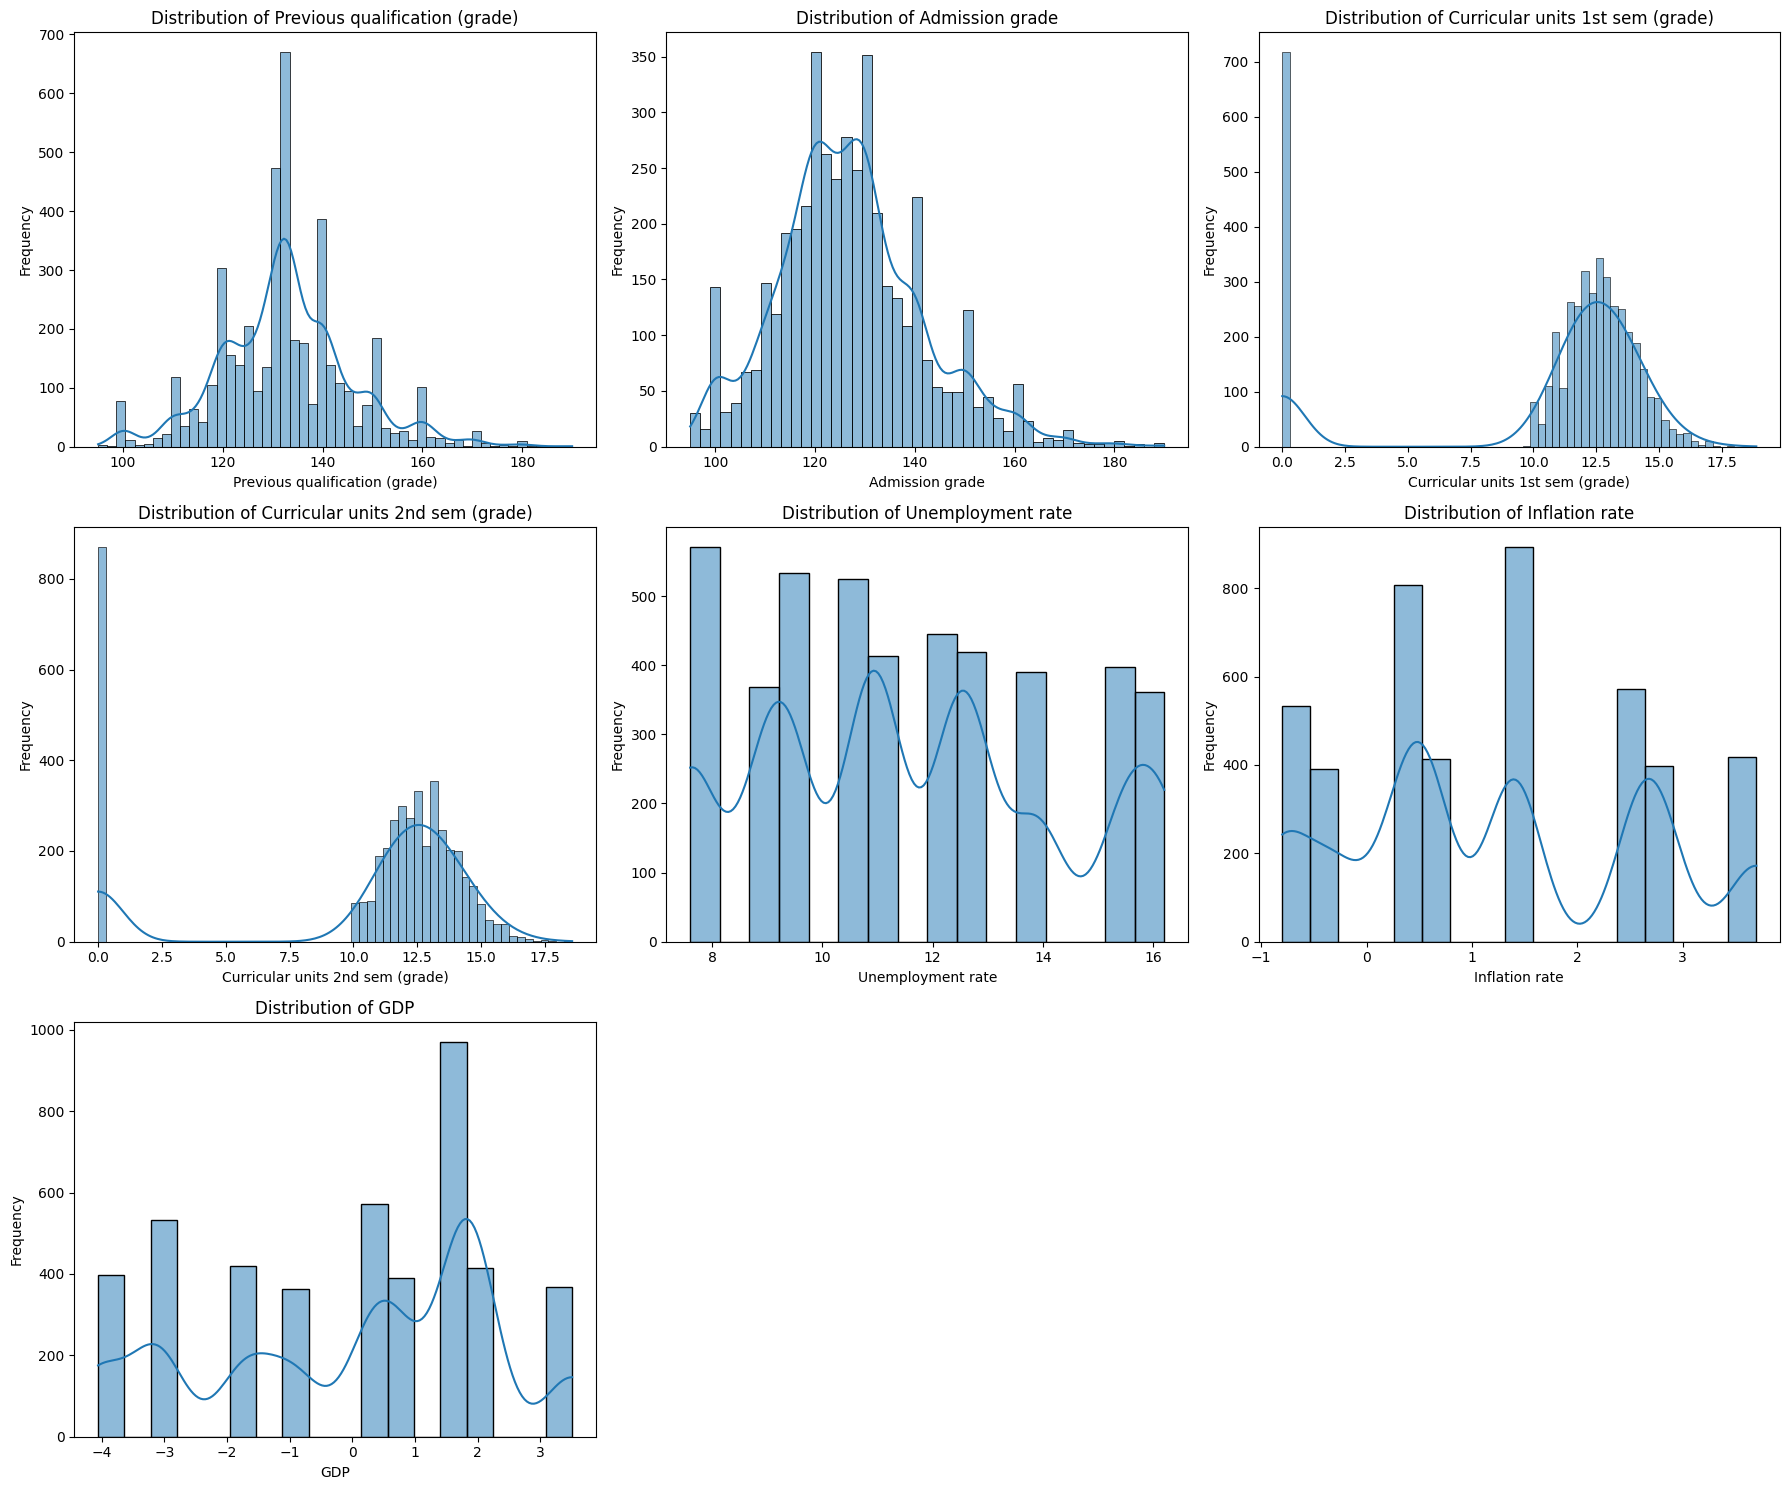

In [ ]:
n_cols = 3  # Number of columns for the grid
n_rows = (len(numerical_for_outliers) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 5))
for i, col in enumerate(numerical_for_outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Generate Count Plots for Categorical Features



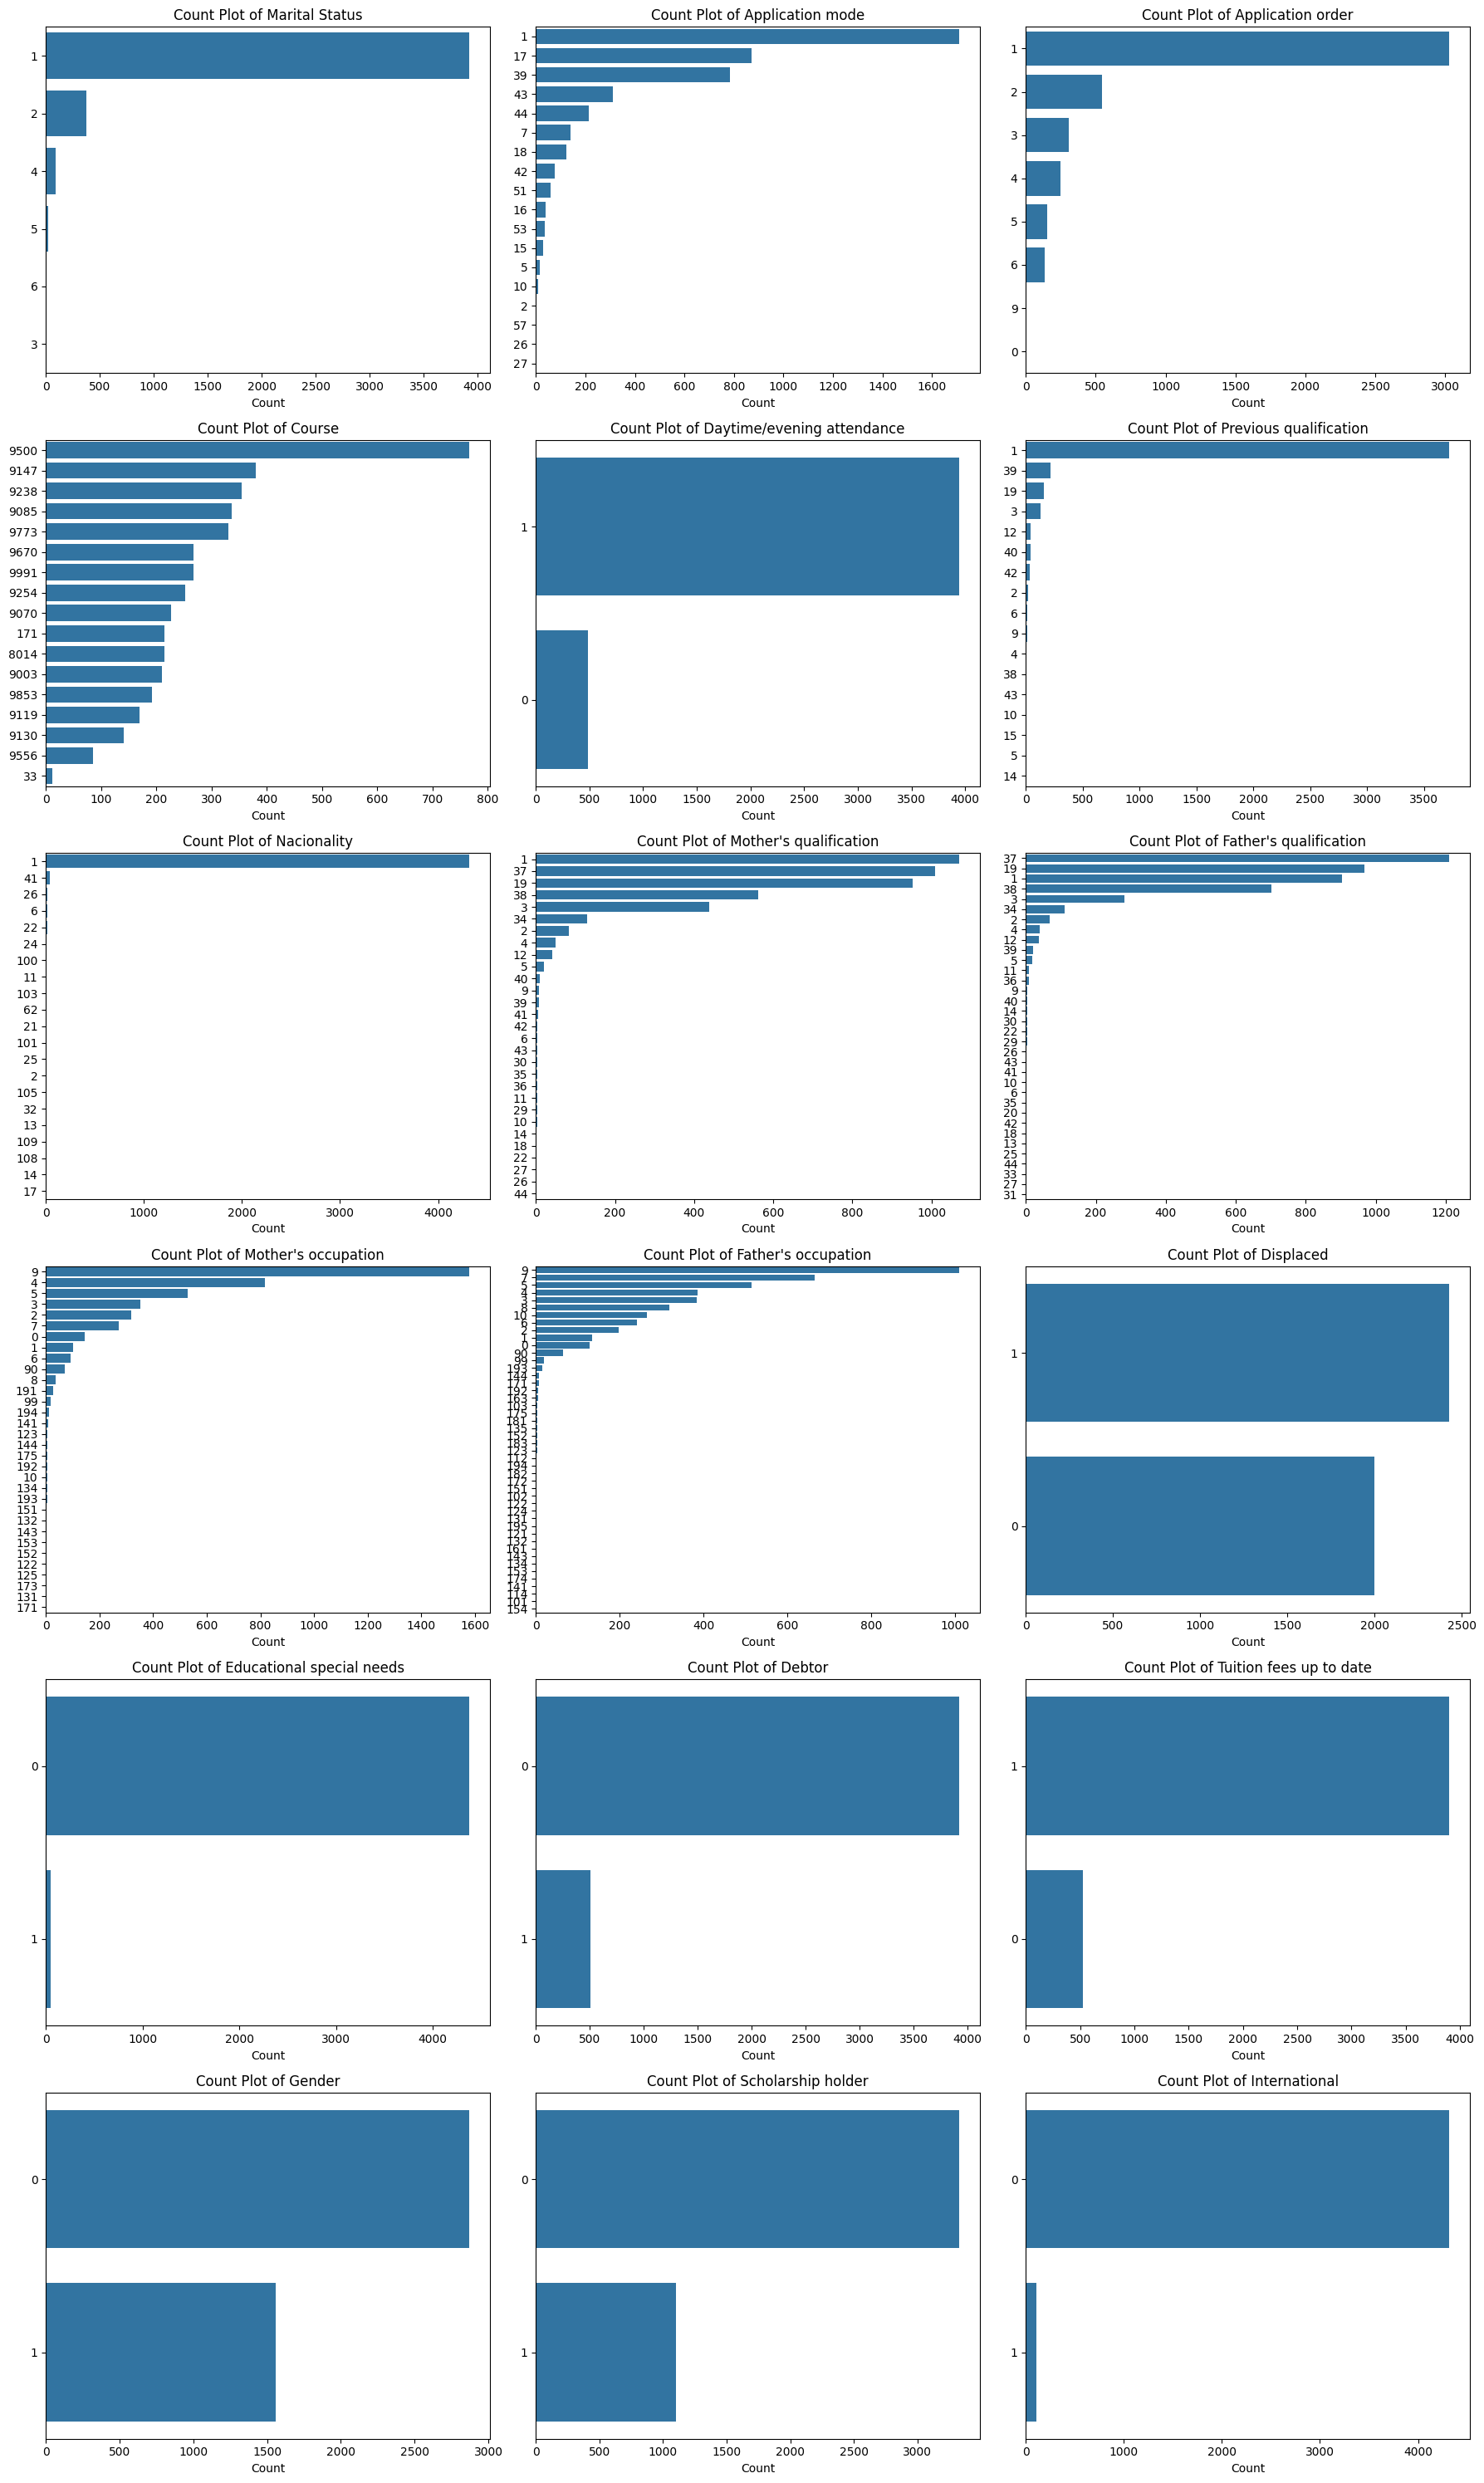

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine the number of rows and columns for the subplots
n_cols = 3  # For example, 3 columns per row
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 5))
for i, col in enumerate(categorical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xlabel('Count')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

## Remove Duplicate Rows



In [ ]:
print(f"Initial number of rows: {df.shape[0]}")
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    df_cleaned = df.drop_duplicates().copy()
    print(f"Number of rows after removing duplicates: {df_cleaned.shape[0]}")
    df = df_cleaned
else:
    print("No duplicate rows found.")

Initial number of rows: 4424
No duplicate rows found.


## Handle Outliers in Numerical Features



In [ ]:
for col in numerical_for_outliers:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Descriptive statistics for numerical columns after 1st and 99th percentile capping:")
print(df[numerical_for_outliers].describe())

Descriptive statistics for numerical columns after 1st and 99th percentile capping:
       Previous qualification (grade)  Admission grade  \
count                     4424.000000      4424.000000   
mean                       132.565077       126.926378   
std                         13.004846        14.186372   
min                        100.000000        99.000000   
25%                        125.000000       117.900000   
50%                        133.100000       126.100000   
75%                        140.000000       134.800000   
max                        170.000000       166.831000   

       Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)  \
count                       4424.000000                       4424.000000   
mean                          10.634238                         10.224007   
std                            4.835557                          5.203243   
min                            0.000000                          0.000000   
25%     

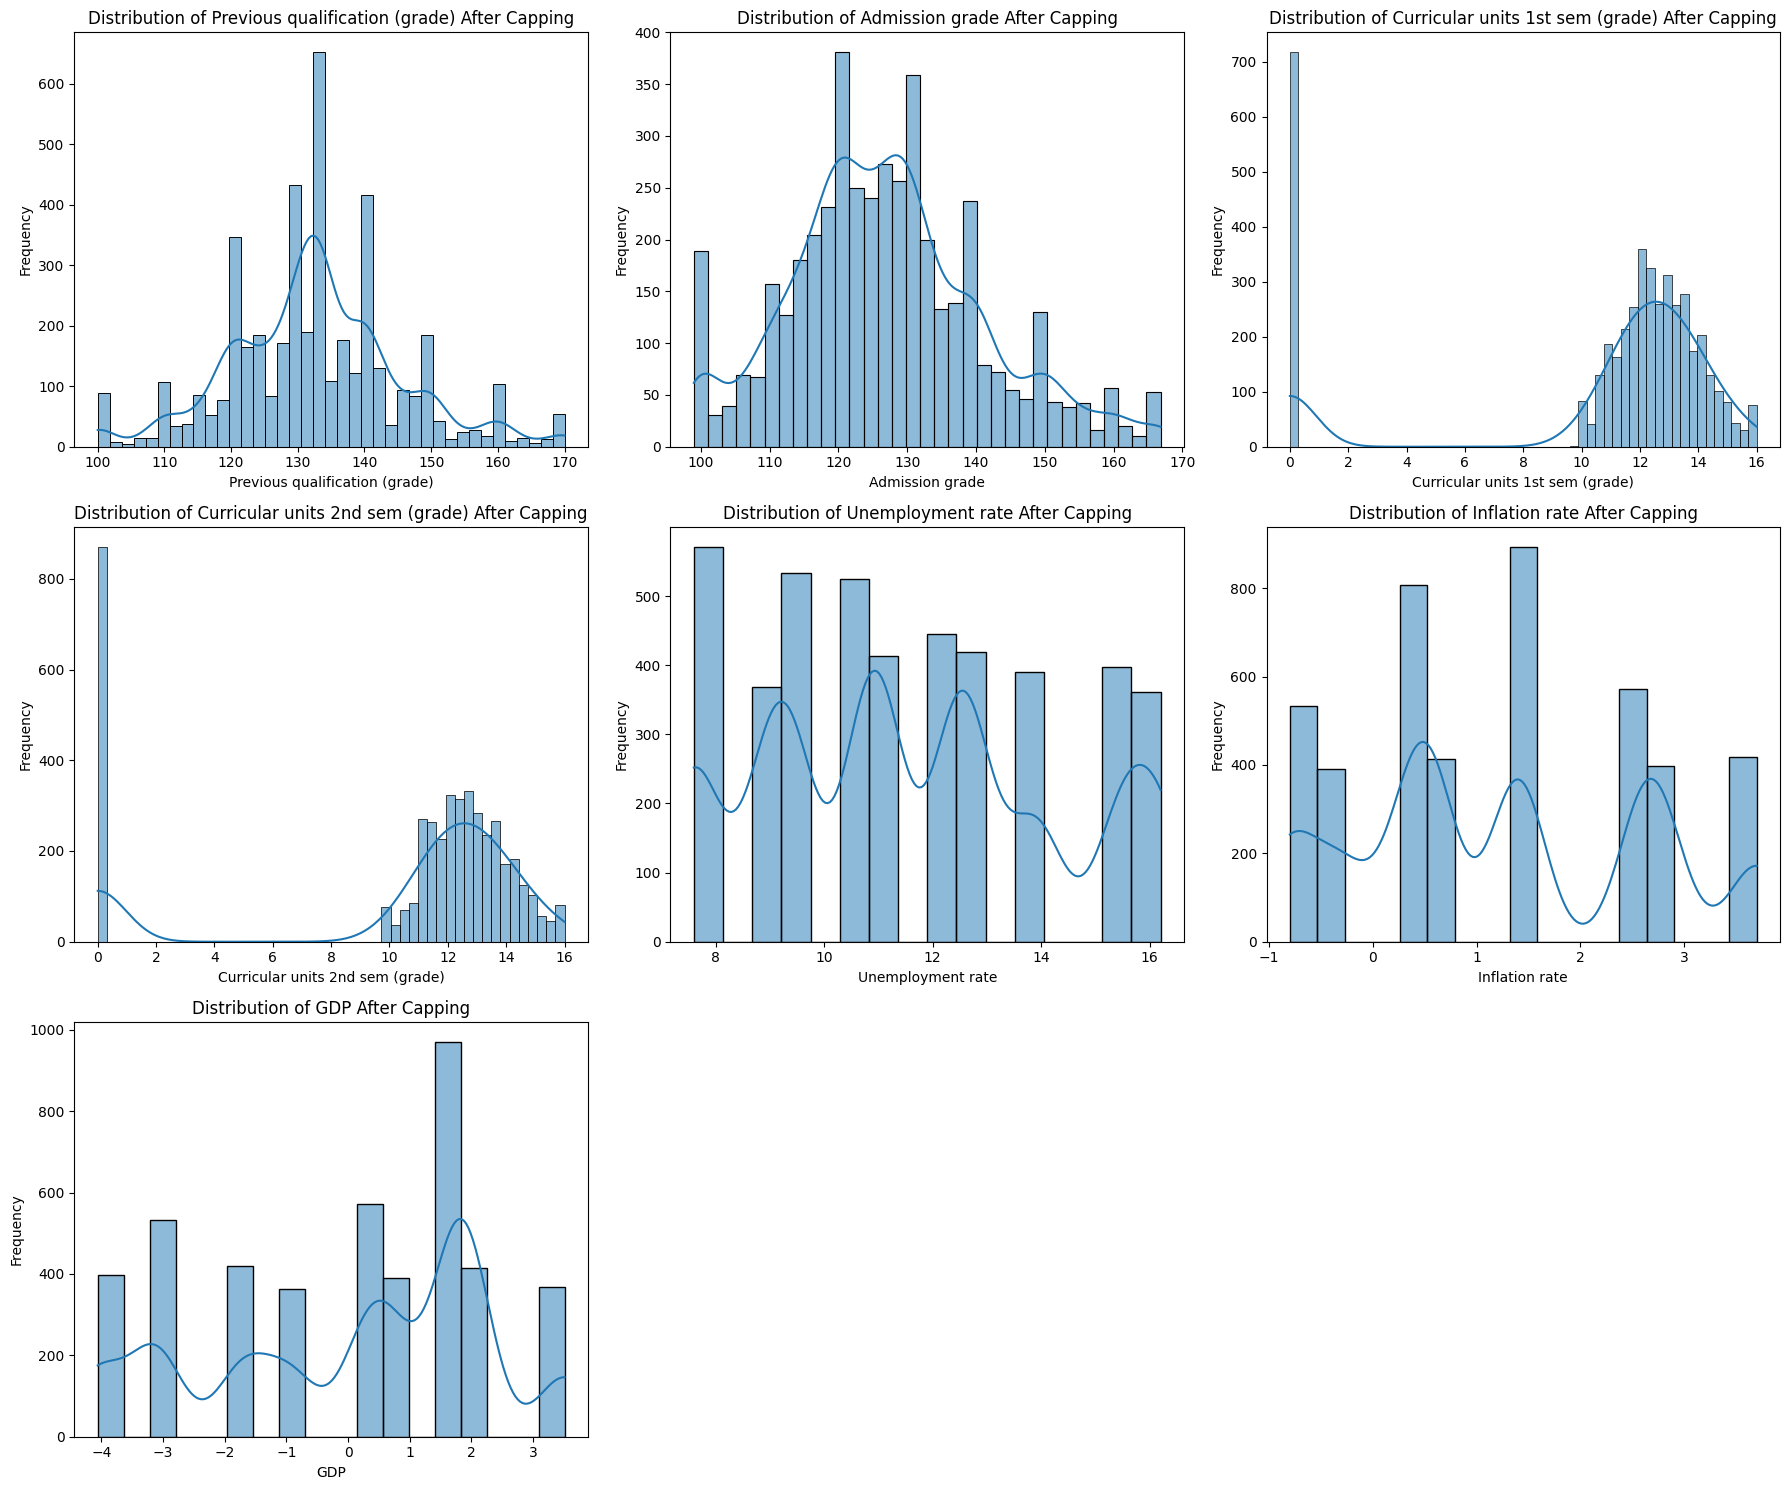

In [ ]:
n_cols = 3  # Number of columns for the grid
n_rows = (len(numerical_for_outliers) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 5))
for i, col in enumerate(numerical_for_outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} After Capping')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Encode Categorical Features




In [ ]:
print(f"Shape of DataFrame before one-hot encoding: {df.shape}")

# Apply one-hot encoding to the identified categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print(f"\nShape of DataFrame after one-hot encoding: {df_encoded.shape}")
print("\nFirst 5 rows of the DataFrame after one-hot encoding:")
print(df_encoded.head())

Shape of DataFrame before one-hot encoding: (4424, 37)

Shape of DataFrame after one-hot encoding: (4424, 245)

First 5 rows of the DataFrame after one-hot encoding:
   Previous qualification (grade)  Admission grade  Age at enrollment  \
0                           122.0            127.3                 20   
1                           160.0            142.5                 19   
2                           122.0            124.8                 19   
3                           122.0            119.6                 20   
4                           100.0            141.5                 45   

   Curricular units 1st sem (credited)  Curricular units 1st sem (enrolled)  \
0                                    0                                    0   
1                                    0                                    6   
2                                    0                                    6   
3                                    0                                    6   


## Scale Numerical Features


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns in df_encoded, excluding the 'target' column
# The target column is currently of 'object' type in df_encoded.
# All other numerical columns (both original and those created by one-hot encoding for binary features) are int or float.

# First, exclude the 'target' column from the DataFrame for scaling
X = df_encoded.drop(columns=['target'])

# Identify numerical columns for scaling
# These are columns that were not one-hot encoded and are continuous numerical features
# We already have `numerical_for_outliers` from a previous step, which is a good candidate list
numerical_cols_to_scale = numerical_for_outliers

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the identified numerical features
X[numerical_cols_to_scale] = scaler.fit_transform(X[numerical_cols_to_scale])

# Re-assign the processed numerical columns back to df_encoded (if df_encoded was used as the base)
# However, since X was created as a copy, we will just use X moving forward as the preprocessed DataFrame
# For clarity, let's keep the name `df_processed` for the final DataFrame after all preprocessing steps.
df_processed = X.copy()
df_processed['target'] = df_encoded['target']

print("Descriptive statistics for scaled numerical columns:")
print(df_processed[numerical_cols_to_scale].describe())

Descriptive statistics for scaled numerical columns:
       Previous qualification (grade)  Admission grade  \
count                    4.424000e+03     4.424000e+03   
mean                     2.062244e-15    -6.279887e-16   
std                      1.000113e+00     1.000113e+00   
min                     -2.504356e+00    -1.968758e+00   
25%                     -5.817779e-01    -6.363429e-01   
50%                      4.113725e-02    -5.825810e-02   
75%                      5.717687e-01     5.550758e-01   
max                      2.878862e+00     2.813202e+00   

       Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)  \
count                      4.424000e+03                      4.424000e+03   
mean                      -1.509743e-16                      1.220643e-16   
std                        1.000113e+00                      1.000113e+00   
min                       -2.199424e+00                     -1.965152e+00   
25%                        7.564871e-02

## Explore Relationships with Target Variable




Generating stacked bar charts for categorical features vs. target...


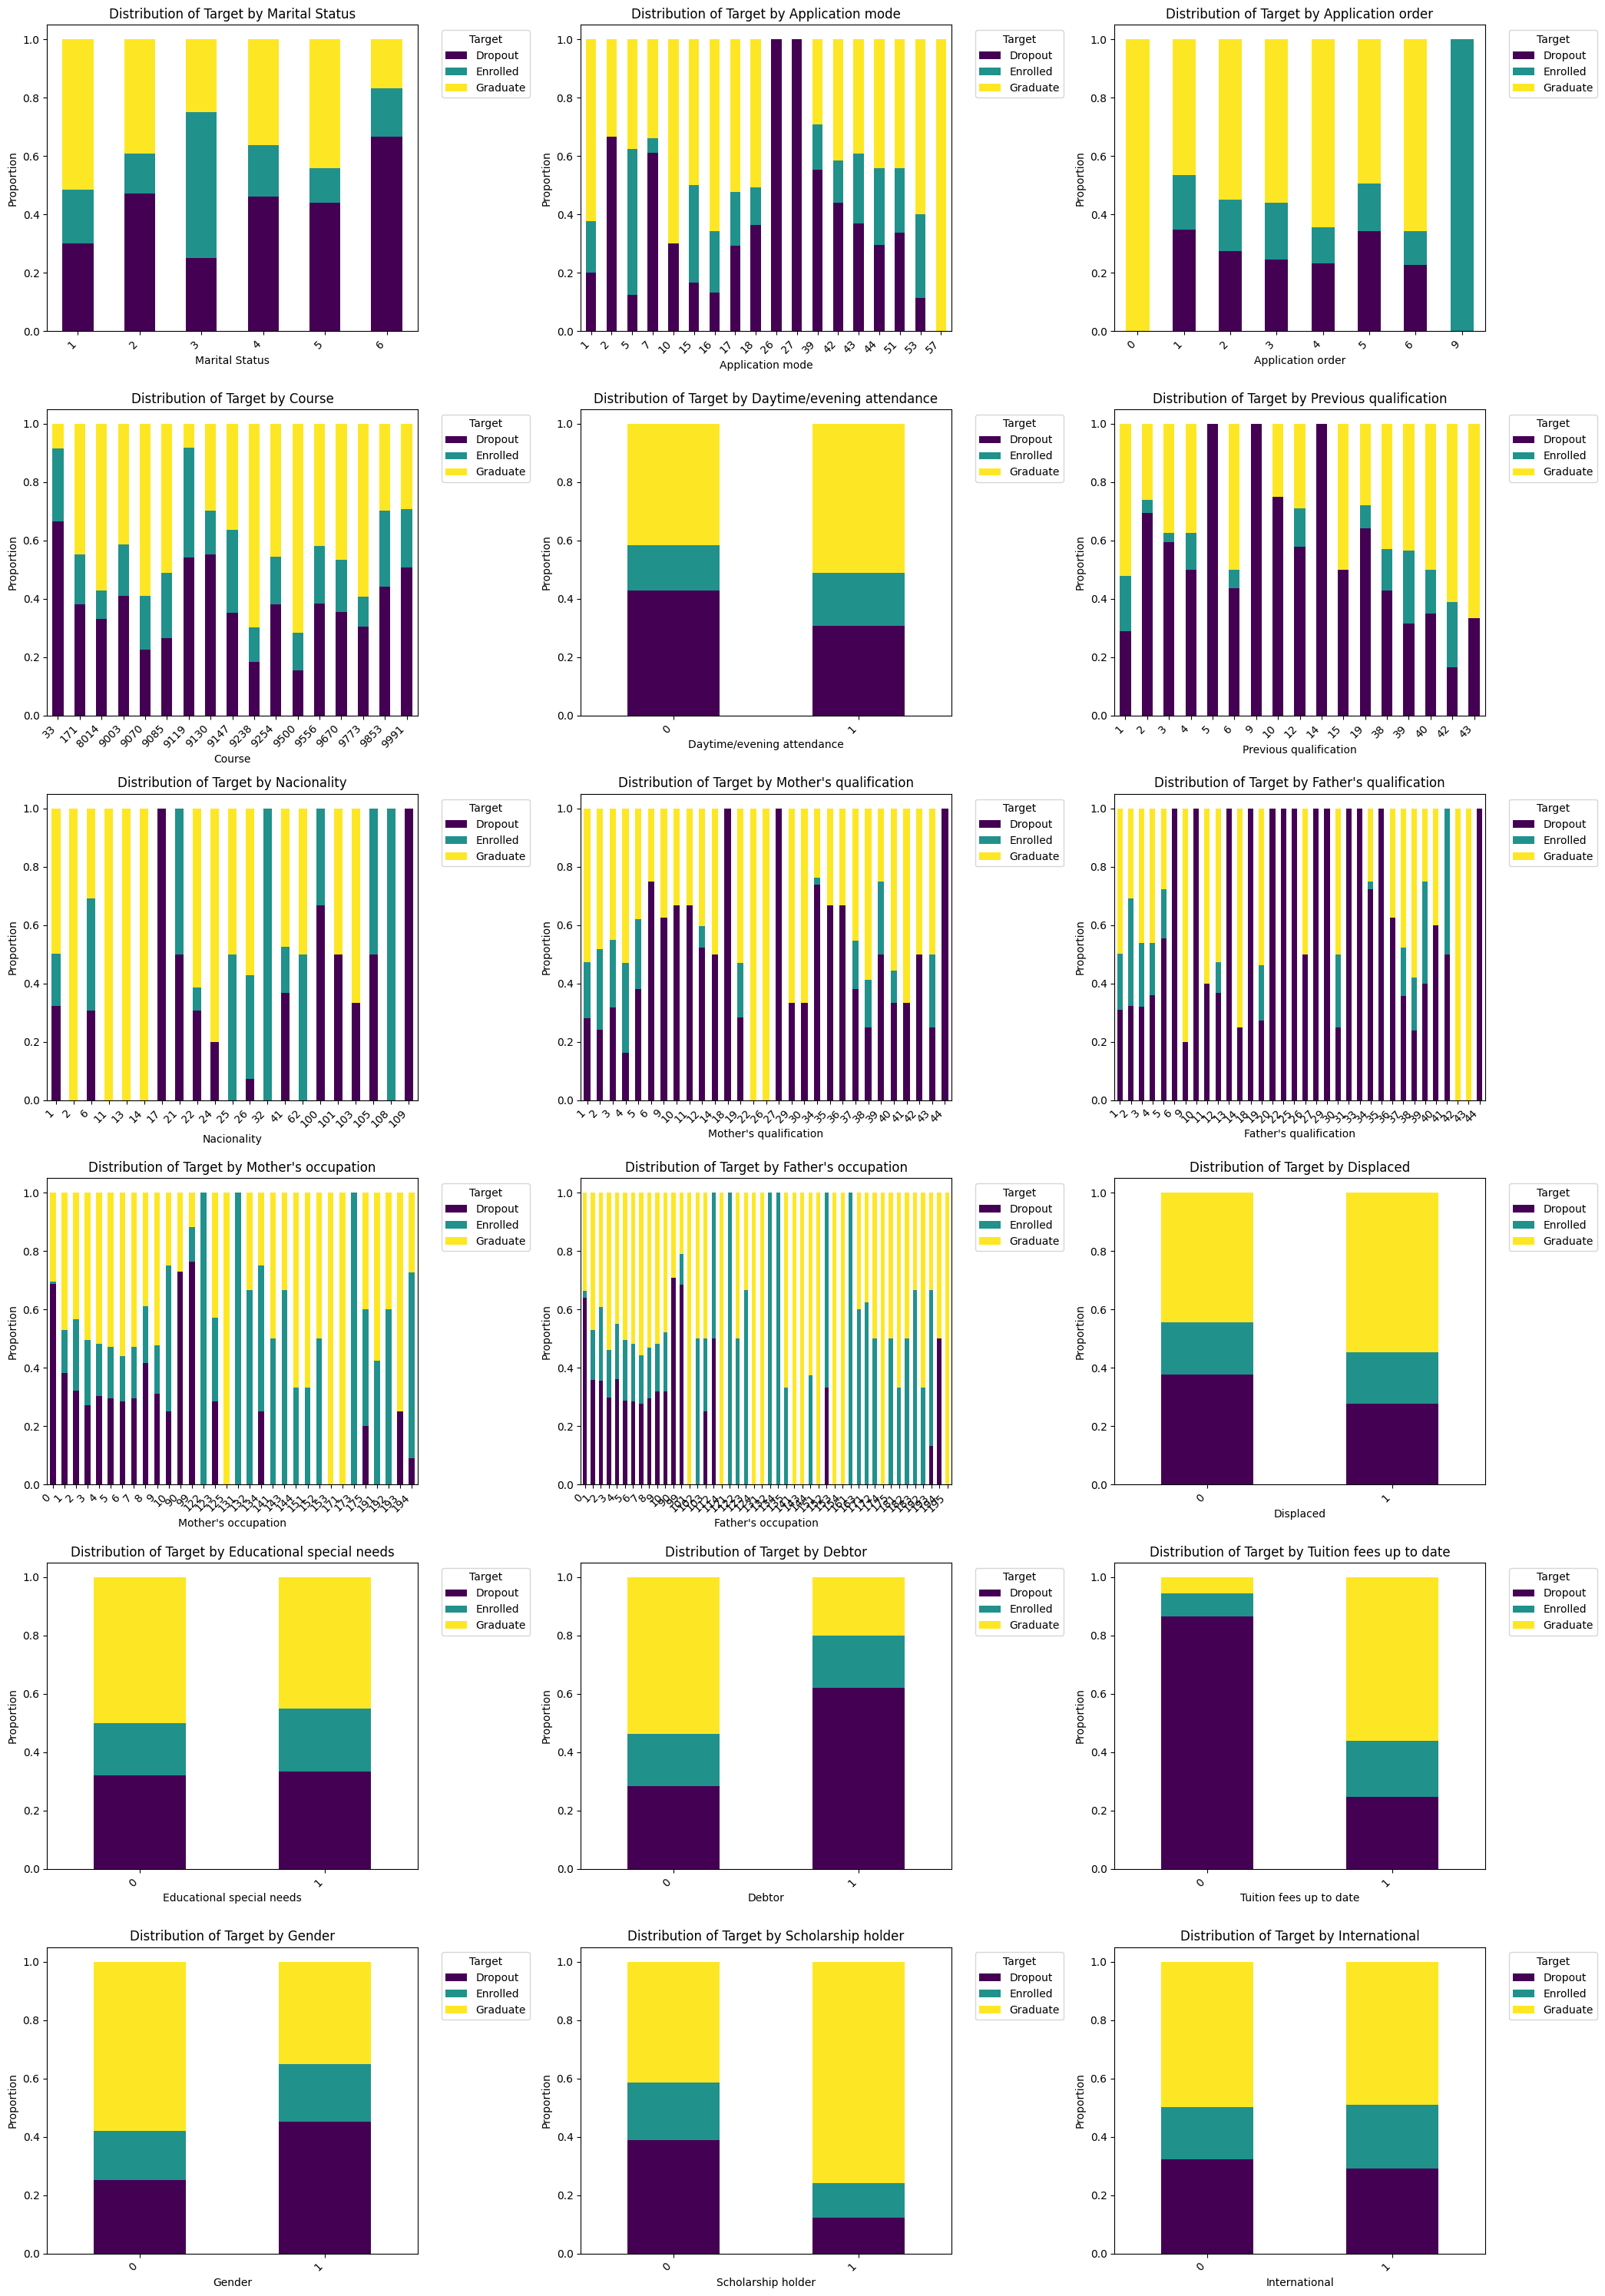

Stacked bar charts generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of original categorical features from the `categorical_features` variable
# The `df` DataFrame still holds the original categorical values

print("Generating stacked bar charts for categorical features vs. target...")

n_cols = 3  # Number of columns for the grid
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 5))

for i, col in enumerate(categorical_features):
    plt.subplot(n_rows, n_cols, i + 1)

    # Create a cross-tabulation to get counts for each category and target class
    ct = pd.crosstab(df[col], df['target'], normalize='index') # normalize='index' for percentages

    ct.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
    plt.title(f'Distribution of Target by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Stacked bar charts generated successfully.")

Generating box plots for numerical features vs. target...


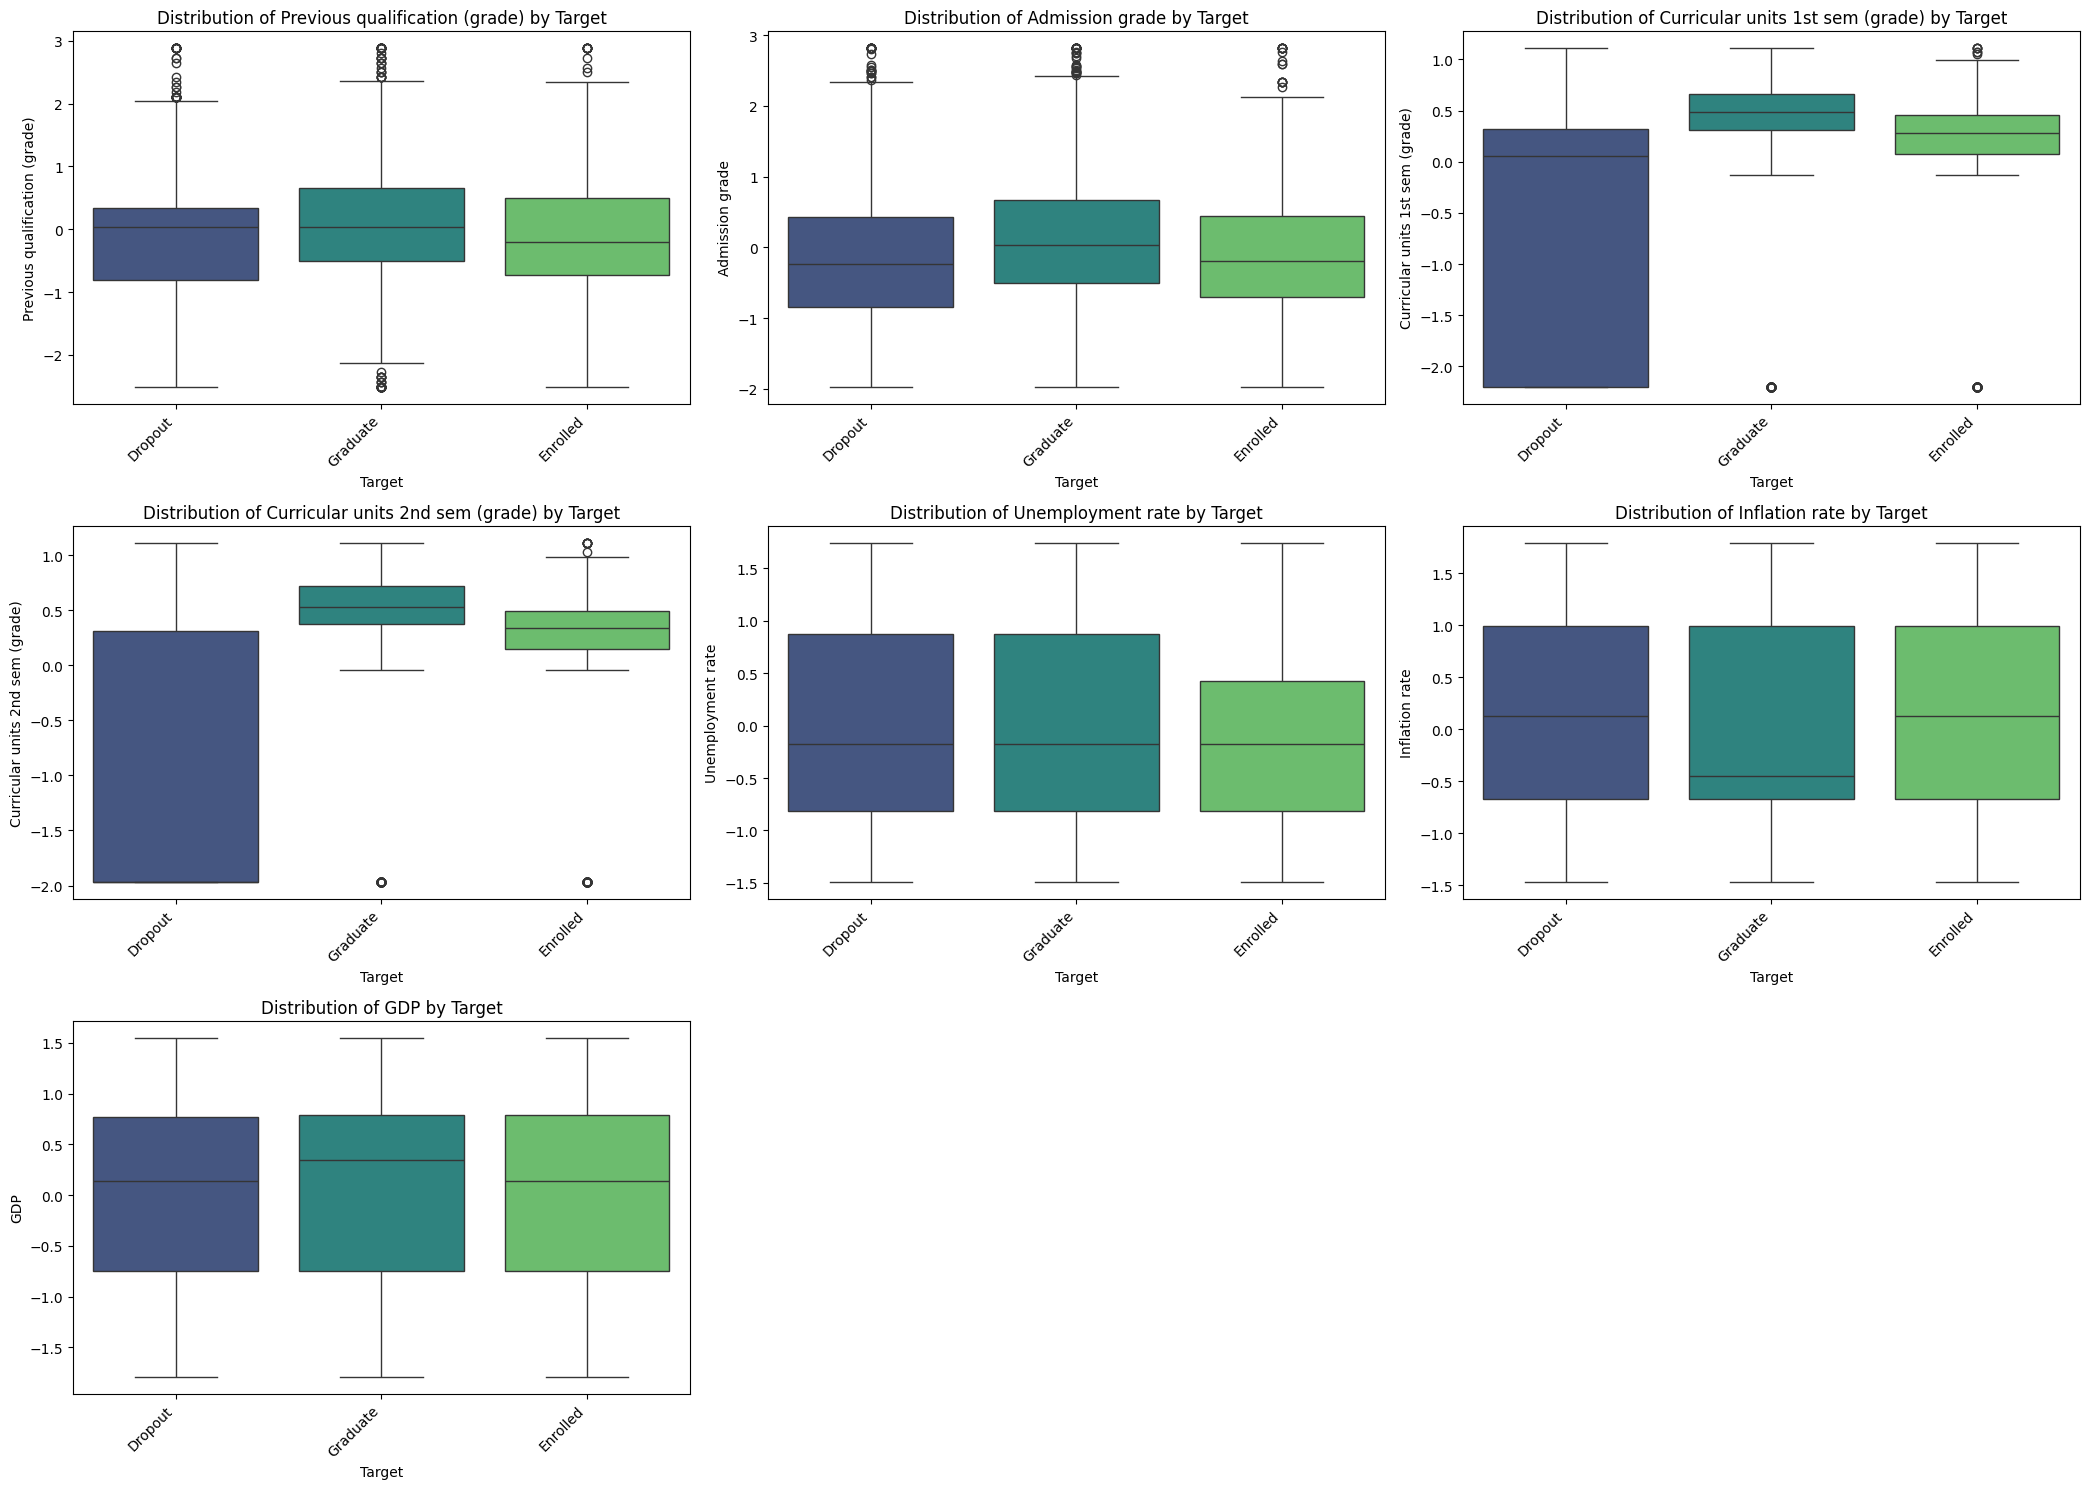

Box plots generated successfully.


In [ ]:
print("Generating box plots for numerical features vs. target...")

n_cols = 3  # Number of columns for the grid
n_rows = (len(numerical_for_outliers) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 5))

for i, col in enumerate(numerical_for_outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_processed['target'], y=df_processed[col], hue=df_processed['target'], palette='viridis', legend=False)
    plt.title(f'Distribution of {col} by Target')
    plt.xlabel('Target')
    plt.ylabel(col)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Box plots generated successfully.")

Correlation Heatmap

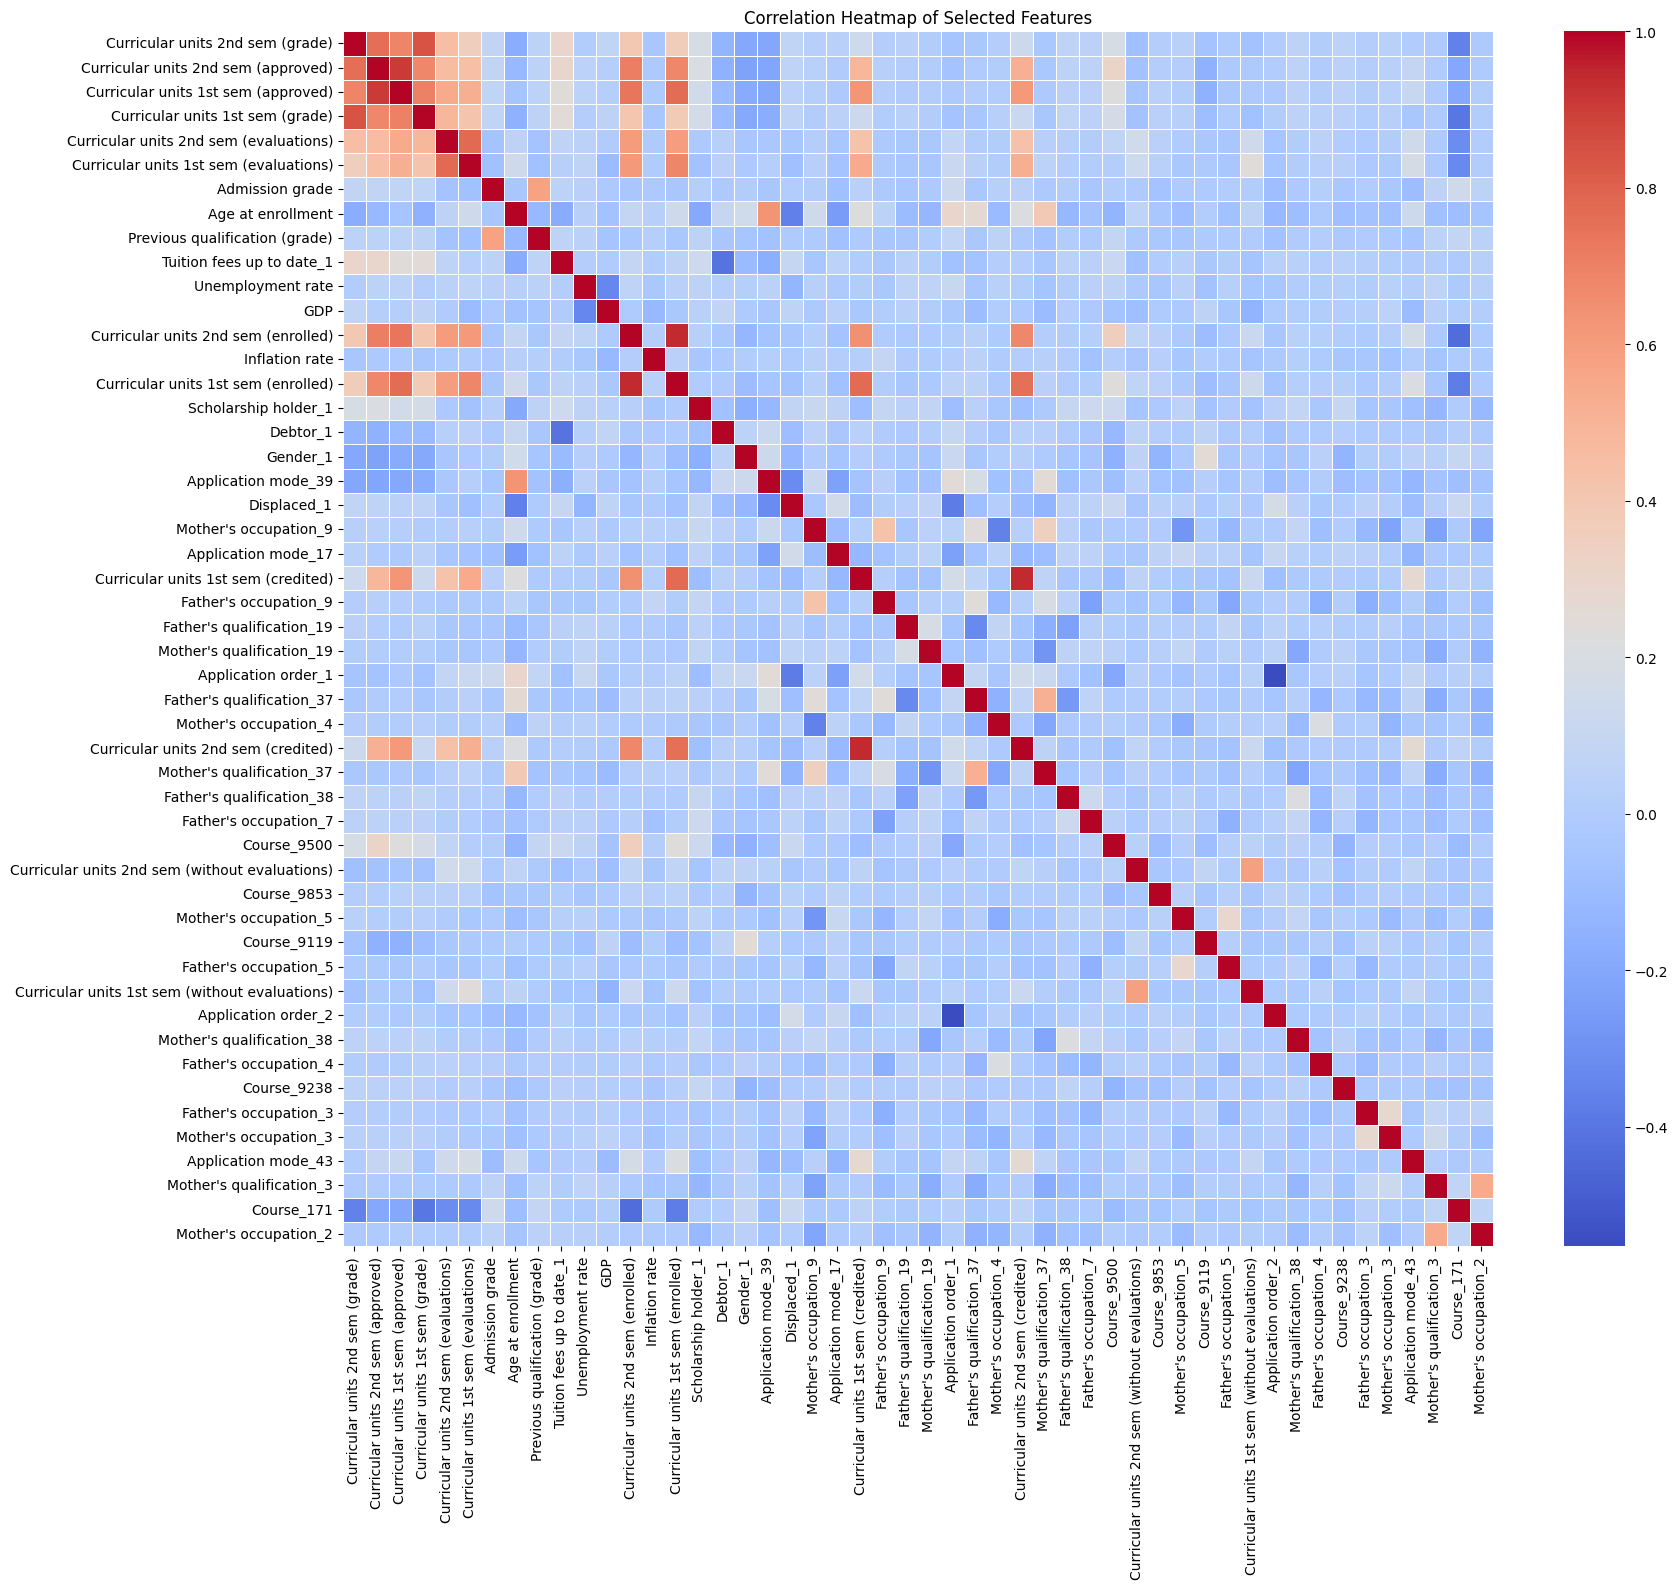

Correlation heatmap generated. Note: For better readability, a heatmap of a smaller subset of highly correlated or most important features could be generated if desired.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert boolean columns in X_selected to numeric (0s and 1s) for correlation calculation
X_selected_numeric = X_selected.copy()
for col in X_selected_numeric.select_dtypes(include='bool').columns:
    X_selected_numeric[col] = X_selected_numeric[col].astype(int)

# Calculate the correlation matrix
correlation_matrix = X_selected_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(18, 16)) # Adjust figure size for better readability with many features
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Features')
plt.tight_layout()
plt.show()

print("Correlation heatmap generated. Note: For better readability, a heatmap of a smaller subset of highly correlated or most important features could be generated if desired.")

## Calculate Feature Importance


Top 20 Most Important Features:
                                    feature  importance
13         Curricular units 2nd sem (grade)    0.103196
12      Curricular units 2nd sem (approved)    0.100789
6       Curricular units 1st sem (approved)    0.084841
7          Curricular units 1st sem (grade)    0.053442
11   Curricular units 2nd sem (evaluations)    0.037409
5    Curricular units 1st sem (evaluations)    0.037354
1                           Admission grade    0.035606
2                         Age at enrollment    0.035546
0            Previous qualification (grade)    0.032704
240               Tuition fees up to date_1    0.029360
15                        Unemployment rate    0.021571
17                                      GDP    0.021052
10      Curricular units 2nd sem (enrolled)    0.020730
16                           Inflation rate    0.019768
4       Curricular units 1st sem (enrolled)    0.018603
242                    Scholarship holder_1    0.017572
239             

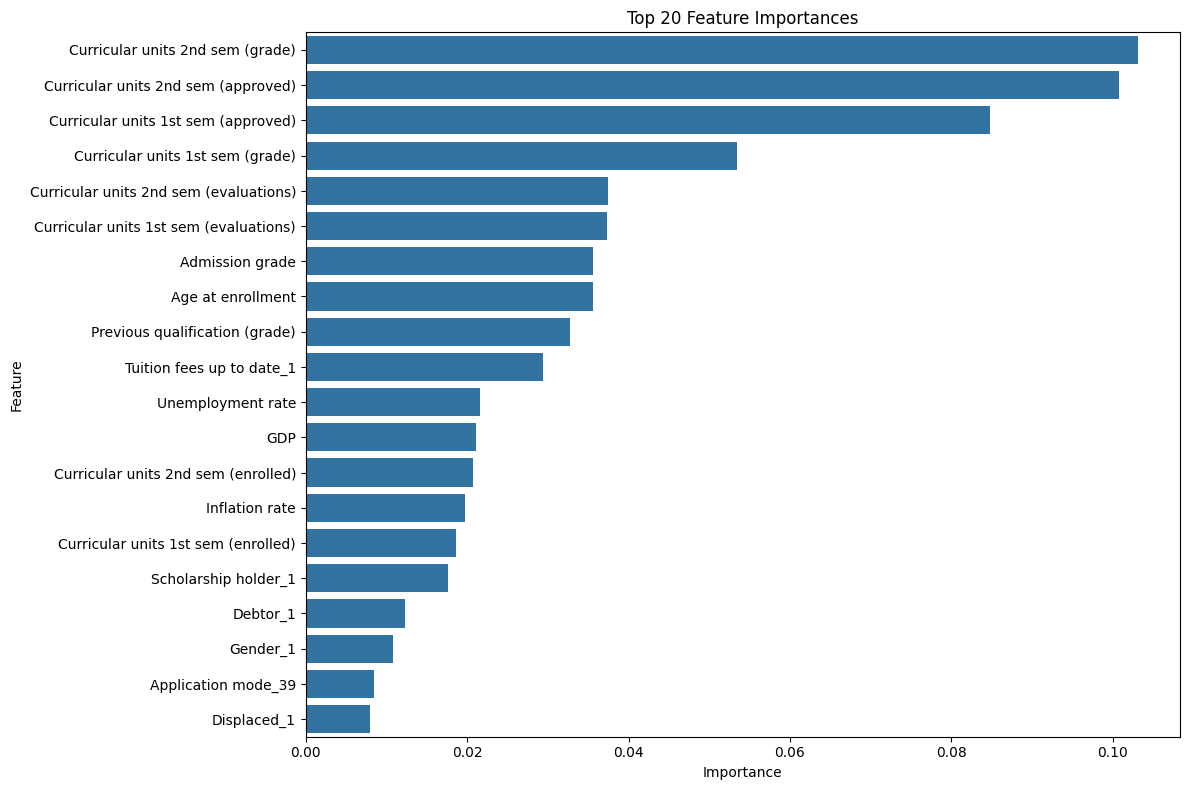

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

# Encode the target variable numerically
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Initialize and train RandomForestClassifier
# Using a fixed random_state for reproducibility
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y_encoded)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importances.head(20))

# Visualize top N important features
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(20))
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Perform Feature Selection


In [ ]:
n_top_features = 50

top_features = feature_importances.head(n_top_features)['feature'].tolist()

X_selected = X[top_features]

print(f"Number of selected features: {len(top_features)}")
print("Selected features:")
for feature in top_features:
    print(f"- {feature}")

print("\nFirst 5 rows of X_selected:")
print(X_selected.head())

Number of selected features: 50
Selected features:
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (approved)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (grade)
- Curricular units 2nd sem (evaluations)
- Curricular units 1st sem (evaluations)
- Admission grade
- Age at enrollment
- Previous qualification (grade)
- Tuition fees up to date_1
- Unemployment rate
- GDP
- Curricular units 2nd sem (enrolled)
- Inflation rate
- Curricular units 1st sem (enrolled)
- Scholarship holder_1
- Debtor_1
- Gender_1
- Application mode_39
- Displaced_1
- Mother's occupation_9
- Application mode_17
- Curricular units 1st sem (credited)
- Father's occupation_9
- Father's qualification_19
- Mother's qualification_19
- Application order_1
- Father's qualification_37
- Mother's occupation_4
- Curricular units 2nd sem (credited)
- Mother's qualification_37
- Father's qualification_38
- Father's occupation_7
- Course_9500
- Curricular units 2nd sem (without evaluations)
- C

## Apply Dimensionality Reduction (PCA)



In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA without specifying n_components to retain all principal components
pca = PCA()

# Fit PCA to the selected features and transform the data
X_pca = pca.fit_transform(X_selected)

print(f"Shape of data after PCA: {X_pca.shape}")

Shape of data after PCA: (4424, 50)


Explained variance ratio of each principal component:
[4.26728282e-01 3.37226979e-01 7.84212167e-02 3.90906529e-02
 2.30958829e-02 1.55106015e-02 1.09036570e-02 8.98321027e-03
 7.34913845e-03 6.43331707e-03 5.43382110e-03 4.18260867e-03
 2.95197968e-03 2.84324431e-03 2.56906428e-03 1.96947061e-03
 1.85330870e-03 1.68360821e-03 1.58070913e-03 1.46741216e-03
 1.36517256e-03 1.27435538e-03 1.18846234e-03 1.15228568e-03
 1.10804772e-03 1.01817543e-03 9.97036382e-04 9.57607755e-04
 8.90483547e-04 8.78734760e-04 8.44032922e-04 7.69312305e-04
 7.59526980e-04 7.01557843e-04 6.21423261e-04 5.94932098e-04
 5.87439109e-04 4.79559954e-04 4.53806591e-04 4.31792445e-04
 4.04905652e-04 3.85896737e-04 3.32853565e-04 3.26303048e-04
 2.55177824e-04 2.48082519e-04 2.23469830e-04 2.15487172e-04
 1.46507226e-04 1.09406161e-04]

Cumulative explained variance:
[0.42672828 0.76395526 0.84237648 0.88146713 0.90456301 0.92007362
 0.93097727 0.93996048 0.94730962 0.95374294 0.95917676 0.96335937
 0.96631135 0.96

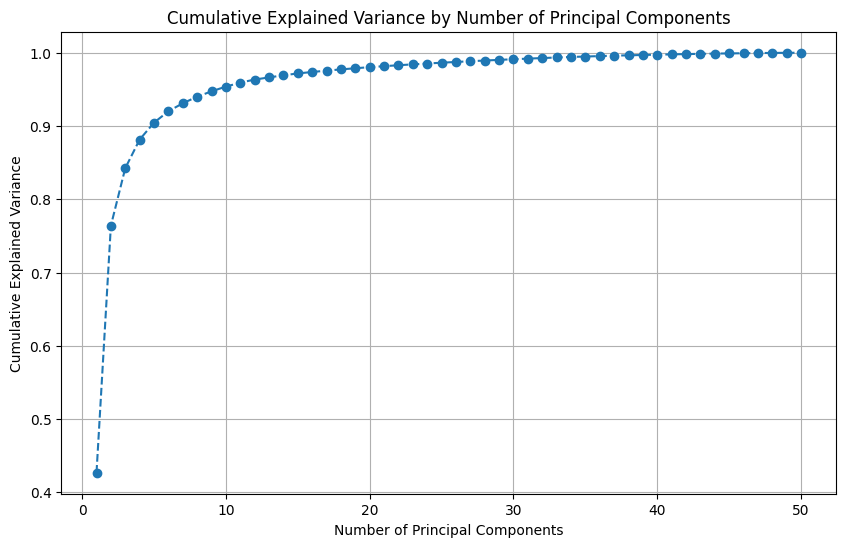

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate the cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Explained variance ratio of each principal component:")
print(explained_variance_ratio)

print("\nCumulative explained variance:")
print(cumulative_explained_variance)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

## Prepare Data for Modeling



In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (3539, 50)
Shape of X_test: (885, 50)
Shape of y_train: (3539,)
Shape of y_test: (885,)


## Train and Evaluate Logistic Regression



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialize and train the Logistic Regression model
# Set random_state for reproducibility and max_iter for convergence
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Print the classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       284
           1       0.55      0.36      0.44       159
           2       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885



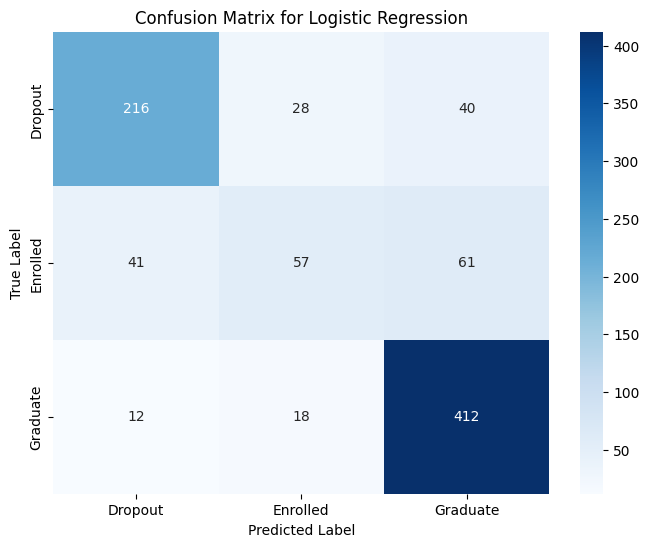

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Train and Evaluate Decision Tree Classifier


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Initialize and train the Decision Tree Classifier model
# Set random_state for reproducibility
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Print the classification report
print("Decision Tree Classifier Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.68      0.68       284
           1       0.32      0.34      0.33       159
           2       0.79      0.77      0.78       442

    accuracy                           0.66       885
   macro avg       0.60      0.60      0.60       885
weighted avg       0.67      0.66      0.67       885



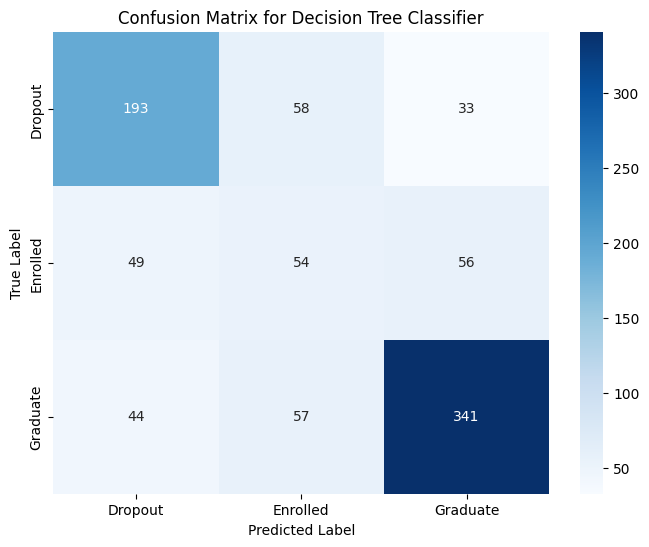

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Train and Evaluate Random Forest Classifier



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize and train the Random Forest Classifier model
# Set random_state for reproducibility
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Print the classification report
print("Random Forest Classifier Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       284
           1       0.57      0.40      0.47       159
           2       0.79      0.92      0.85       442

    accuracy                           0.77       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



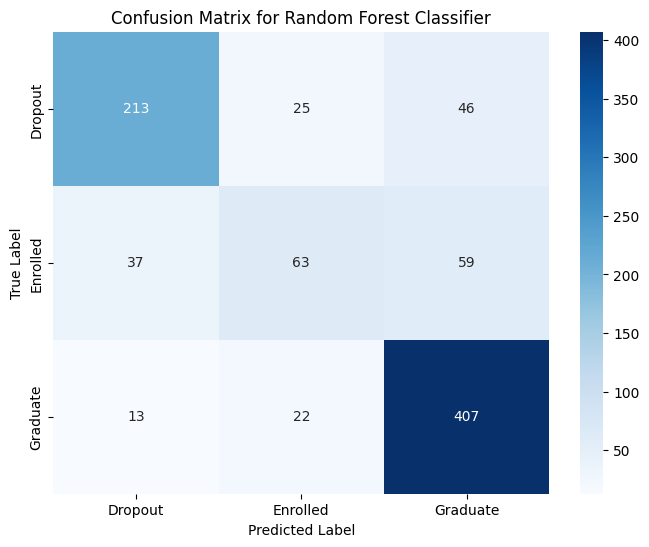

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Train and Evaluate XGBoost Classifier



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the XGBoost Classifier model
# Set objective and num_class for multi-class classification
# Set random_state for reproducibility
xgb_model = XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Print the classification report
print("XGBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       284
           1       0.49      0.43      0.45       159
           2       0.81      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       284
           1       0.49      0.43      0.45       159
           2       0.81      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



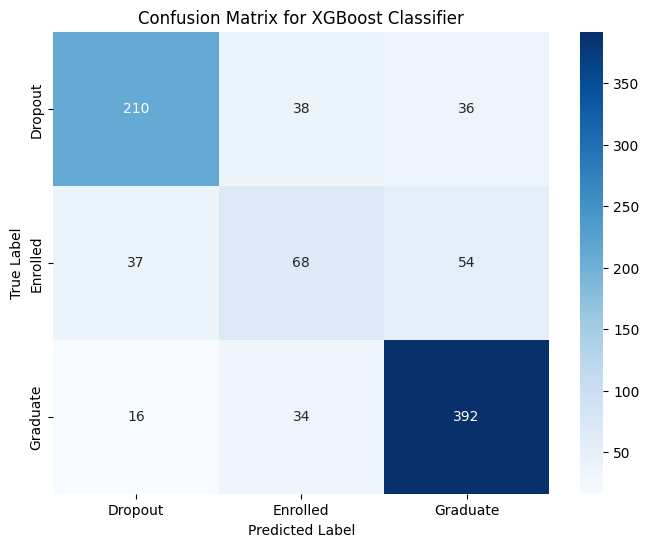

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the XGBoost Classifier model
# Set objective and num_class for multi-class classification
# Set random_state for reproducibility
xgb_model = XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Print the classification report
print("XGBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Generate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Model Comparison and Selection



In [ ]:
from io import StringIO
import pandas as pd # Ensure pandas is imported as it's used in the function

# Classification reports from previous steps
log_reg_report_str = """
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       284
           1       0.55      0.36      0.44       159
           2       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885
"""

dt_report_str = """
              precision    recall  f1-score   support

           0       0.67      0.68      0.68       284
           1       0.32      0.34      0.33       159
           2       0.79      0.77      0.78       442

    accuracy                           0.66       885
   macro avg       0.60      0.60      0.60       885
weighted avg       0.67      0.66      0.67       885
"""

rf_report_str = """
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       284
           1       0.57      0.40      0.47       159
           2       0.79      0.92      0.85       442

    accuracy                           0.77       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885
"""

xgb_report_str = """
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       284
           1       0.49      0.43      0.45       159
           2       0.81      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885
"""

# Function to parse classification report string into a dictionary of metrics
def parse_classification_report(report_string):
    metrics = {}
    lines = report_string.split('\n')

    # Extract accuracy first, as its placement can be tricky with pd.read_csv
    for line in lines:
        if 'accuracy' in line and 'macro avg' not in line and 'weighted avg' not in line:
            # Example: 'accuracy                           0.77       885'
            parts = line.split()
            if len(parts) >= 2:
                try:
                    metrics['accuracy'] = float(parts[-2]) # Accuracy value is usually second to last
                except ValueError: # Fallback if direct parsing fails
                    metrics['accuracy'] = pd.NA
            else:
                metrics['accuracy'] = pd.NA
            break

    # Use pandas for the rest of the metrics, now with raw string for sep
    report_df = pd.read_csv(StringIO(report_string), sep=r'\s\s+', engine='python', index_col=0)

    # Ensure 'f1-score' column exists for class labels
    metrics['f1_score_class_0'] = report_df.loc['0', 'f1-score'] if '0' in report_df.index and 'f1-score' in report_df.columns else pd.NA
    metrics['f1_score_class_1'] = report_df.loc['1', 'f1-score'] if '1' in report_df.index and 'f1-score' in report_df.columns else pd.NA
    metrics['f1_score_class_2'] = report_df.loc['2', 'f1-score'] if '2' in report_df.index and 'f1-score' in report_df.columns else pd.NA
    metrics['macro_avg_f1'] = report_df.loc['macro avg', 'f1-score'] if 'macro avg' in report_df.index and 'f1-score' in report_df.columns else pd.NA
    metrics['weighted_avg_f1'] = report_df.loc['weighted avg', 'f1-score'] if 'weighted avg' in report_df.index and 'f1-score' in report_df.columns else pd.NA

    return metrics

# Parse reports for each model
log_reg_metrics = parse_classification_report(log_reg_report_str)
dt_metrics = parse_classification_report(dt_report_str)
rf_metrics = parse_classification_report(rf_report_str)
xgb_metrics = parse_classification_report(xgb_report_str)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Logistic Regression': log_reg_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}).T # Transpose to have models as rows

print("\nModel Performance Comparison:")
print(comparison_df)


Model Performance Comparison:
                     accuracy  f1_score_class_0  f1_score_class_1  \
Logistic Regression      0.77              0.78              0.44   
Decision Tree            0.66              0.68              0.33   
Random Forest            0.77              0.78              0.47   
XGBoost                  0.76              0.77              0.45   

                     f1_score_class_2  macro_avg_f1  weighted_avg_f1  
Logistic Regression              0.86          0.69             0.76  
Decision Tree                    0.78          0.60             0.67  
Random Forest                    0.85          0.70             0.76  
XGBoost                          0.85          0.69             0.75  


### Model Performance Comparison and Selection

To identify the best performing model, we will compare the key evaluation metrics (Accuracy, F1-score for each class, Macro Avg F1-score, and Weighted Avg F1-score) across all trained models. The `comparison_df` summarizes these metrics:

```
Model Performance Comparison:
                     accuracy  f1_score_class_0  f1_score_class_1  \
Logistic Regression      0.77              0.78              0.44   
Decision Tree            0.66              0.68              0.33   
Random Forest            0.77              0.78              0.47   
XGBoost                  0.76              0.77              0.45   

                     f1_score_class_2  macro_avg_f1  weighted_avg_f1  
Logistic Regression              0.86          0.69             0.76  
Decision Tree                    0.78          0.60             0.67  
Random Forest                    0.85          0.70             0.76  
XGBoost                          0.85          0.69             0.75  
```

**Analysis of Results:**

*   **Accuracy:** Logistic Regression and Random Forest models both achieved the highest accuracy at 0.77. XGBoost followed closely with 0.76, while the Decision Tree performed the worst at 0.66.

*   **F1-score for Class 0 (Dropout):** Logistic Regression and Random Forest performed best for predicting 'Dropout' with an F1-score of 0.78. XGBoost is very close at 0.77.

*   **F1-score for Class 1 (Enrolled):** All models struggled with predicting the 'Enrolled' class. Random Forest showed a slightly better F1-score of 0.47, followed by XGBoost (0.45) and Logistic Regression (0.44). The Decision Tree was significantly lower at 0.33.

*   **F1-score for Class 2 (Graduate):** All models performed well for the 'Graduate' class. Logistic Regression achieved the highest F1-score of 0.86, with Random Forest and XGBoost close behind at 0.85.

*   **Macro Avg F1-score:** This metric considers the average F1-score per class, treating all classes equally. Random Forest has the highest Macro Avg F1-score of 0.70, indicating its superior performance when class imbalance is considered. Logistic Regression and XGBoost both have 0.69.

*   **Weighted Avg F1-score:** This metric accounts for class imbalance by weighting the F1-score of each class by its support. Logistic Regression and Random Forest both achieved the highest Weighted Avg F1-score of 0.76, with XGBoost slightly lower at 0.75.

**Conclusion:**

Based on a holistic evaluation of the metrics, the **Random Forest Classifier** appears to be the best performing model. It achieves the highest accuracy and macro F1-score, and ties for the highest weighted F1-score with Logistic Regression. While all models struggle with the 'Enrolled' class, Random Forest shows a marginally better performance in this category compared to Logistic Regression and XGBoost. The Decision Tree Classifier consistently performed the worst across all metrics.

The Random Forest model offers a good balance between overall accuracy and balanced performance across all classes, making it the most robust choice for this multi-class classification problem.

## Save Best Model and Metrics



In [ ]:
import joblib

# Save the Random Forest model
joblib.dump(random_forest_model, 'best_random_forest_model.joblib')
print("Random Forest model saved as 'best_random_forest_model.joblib'")

Random Forest model saved as 'best_random_forest_model.joblib'


In [ ]:
import json

# Convert numpy floats in rf_metrics to standard Python floats for JSON serialization
rf_metrics_serializable = {k: float(v) if isinstance(v, (float, int)) or (isinstance(v, (type(None), pd.NA)) and pd.isna(v)) else v for k, v in rf_metrics.items()}

# Save the performance metrics to a JSON file
with open('best_random_forest_metrics.json', 'w') as f:
    json.dump(rf_metrics_serializable, f, indent=4)

print("Random Forest model metrics saved as 'best_random_forest_metrics.json'")

Random Forest model metrics saved as 'best_random_forest_metrics.json'


## Save StandardScaler



In [ ]:
import joblib

# Save the StandardScaler object
joblib.dump(scaler, 'standard_scaler.joblib')
print("StandardScaler saved as 'standard_scaler.joblib'")

StandardScaler saved as 'standard_scaler.joblib'


In [ ]:
import os

# List files in the current directory to verify the saved scaler
print("Files in current directory:")
print(os.listdir('.'))

Files in current directory:
['.config', 'best_random_forest_model.joblib', 'best_random_forest_metrics.json', 'standard_scaler.joblib', 'students_dropout_academic_success.csv', 'sample_data']


## Prepare Data for Explanations



In [ ]:
X_explain = X_selected.copy()
y_explain = y_encoded.copy()

print(f"Shape of X_explain: {X_explain.shape}")
print(f"Shape of y_explain: {y_explain.shape}")

Shape of X_explain: (4424, 50)
Shape of y_explain: (4424,)


## Calculate SHAP Values


In [ ]:
import shap

# Load the best_random_forest_model if not already in memory
# import joblib
# best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Initialize a SHAP TreeExplainer with the best Random Forest model
explainer = shap.TreeExplainer(best_random_forest_model)

# Calculate SHAP values for X_explain
shap_values = explainer.shap_values(X_explain)

print("SHAP explainer initialized and SHAP values calculated.")
# The shap_values will be a list of arrays for multi-output models, or a single array for single-output.
# For multi-class classification (as indicated by LabelEncoder with 3 classes), shap_values will be a list of 3 arrays.
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Number of outputs (classes) in shap_values: {len(shap_values)}")
    print(f"Shape of SHAP values for the first class: {shap_values[0].shape}")
else:
    print(f"Shape of SHAP values: {shap_values.shape}")

SHAP explainer initialized and SHAP values calculated.
Type of shap_values: <class 'numpy.ndarray'>
Shape of SHAP values: (4424, 50, 3)


Generating SHAP summary plot for all classes...


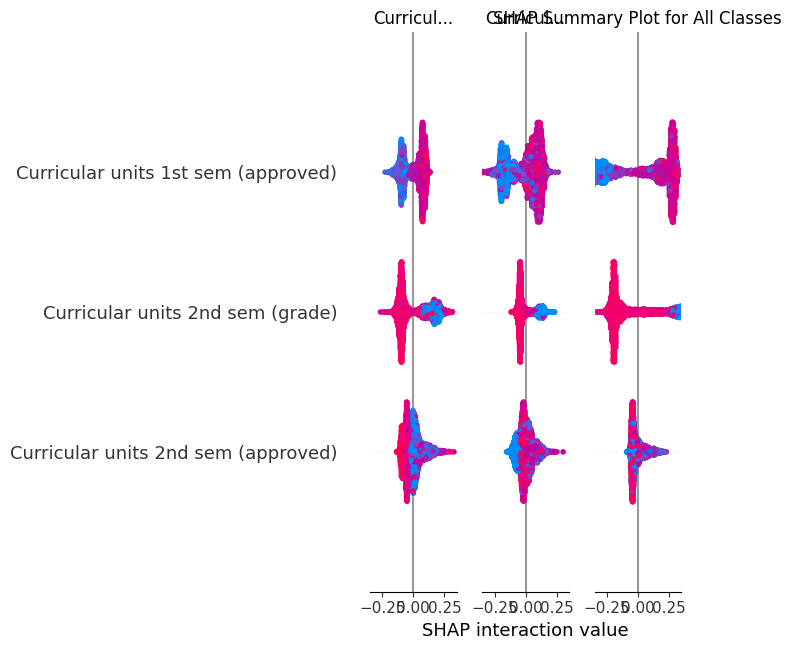

SHAP summary plot generated.


In [ ]:
import matplotlib.pyplot as plt

# Assuming shap_values is a list of arrays (one for each class)
# For multi-class, shap.summary_plot can take a list of shap_values

print("Generating SHAP summary plot for all classes...")
# Create a mapping from encoded labels back to original class names
class_names = le.inverse_transform([0, 1, 2]) # Assuming 0, 1, 2 are the encoded classes

shap.summary_plot(shap_values, X_explain, class_names=class_names, show=False)
plt.title('SHAP Summary Plot for All Classes')
plt.tight_layout()
plt.show()

print("SHAP summary plot generated.")

Generating SHAP dependence plots for the top 3 features...


<Figure size 1000x600 with 0 Axes>

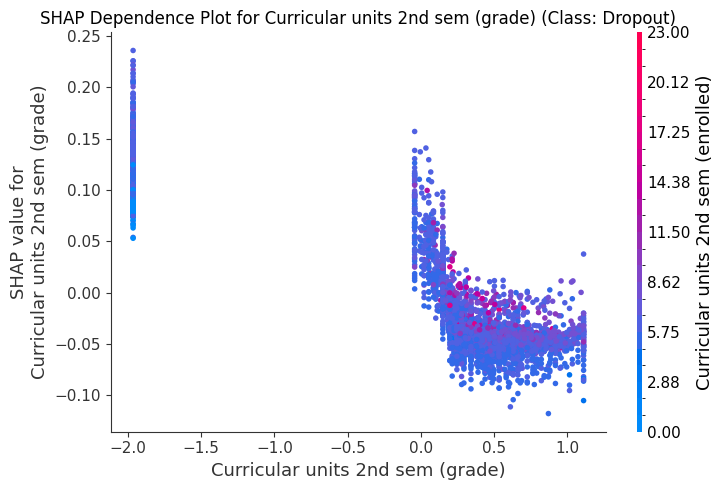

<Figure size 1000x600 with 0 Axes>

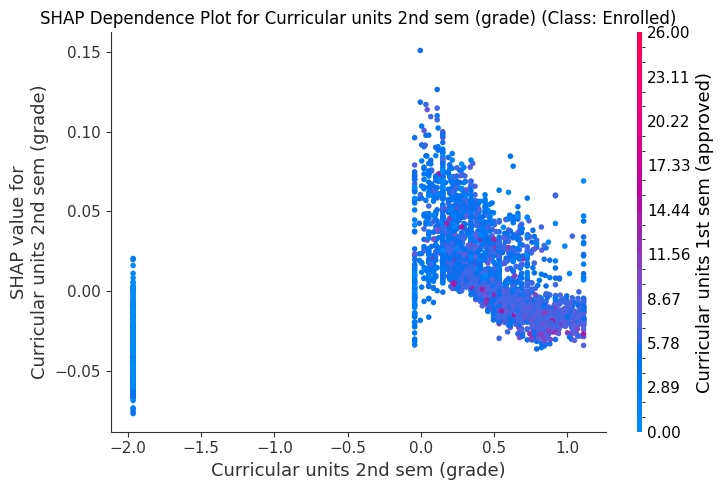

<Figure size 1000x600 with 0 Axes>

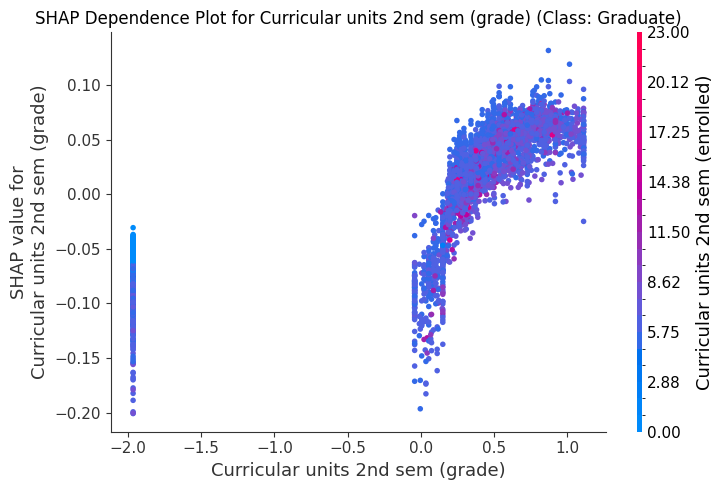

<Figure size 1000x600 with 0 Axes>

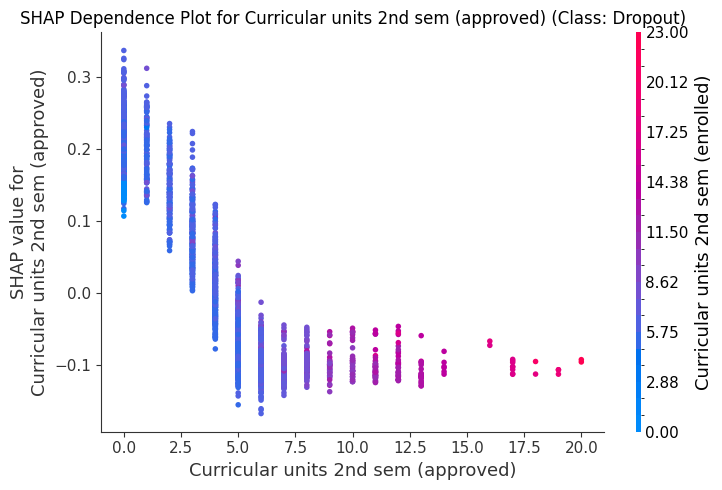

<Figure size 1000x600 with 0 Axes>

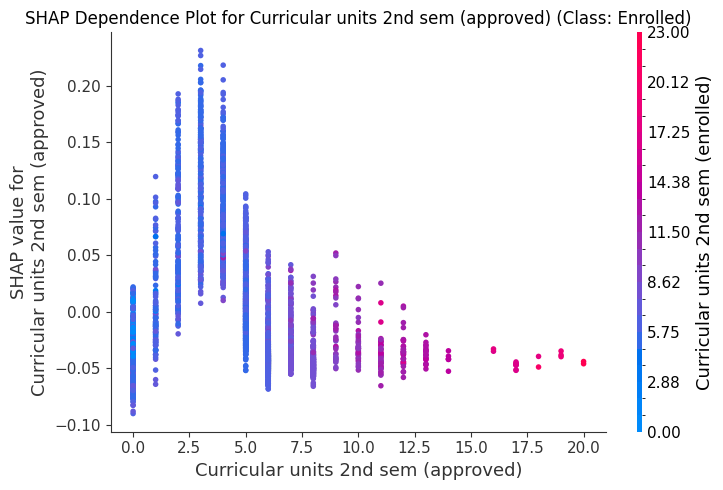

<Figure size 1000x600 with 0 Axes>

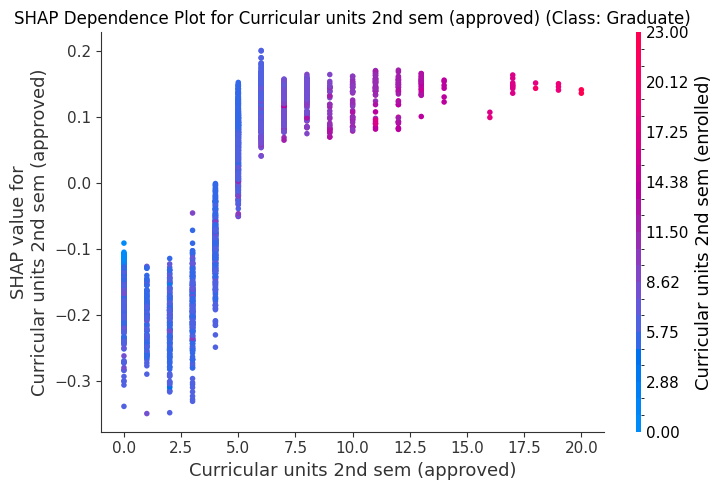

<Figure size 1000x600 with 0 Axes>

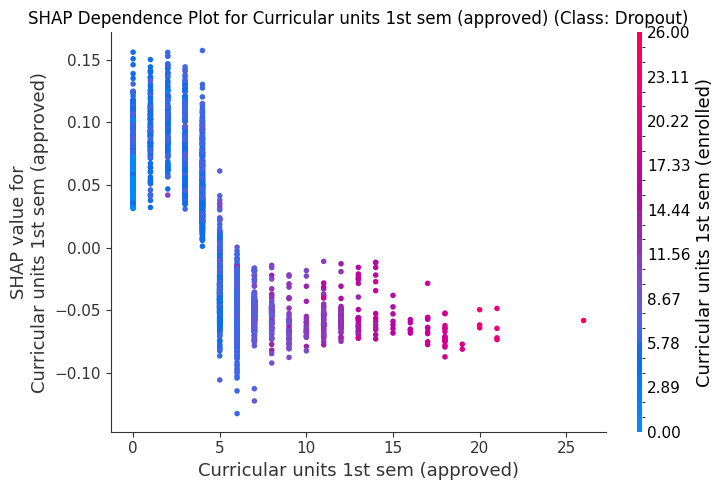

<Figure size 1000x600 with 0 Axes>

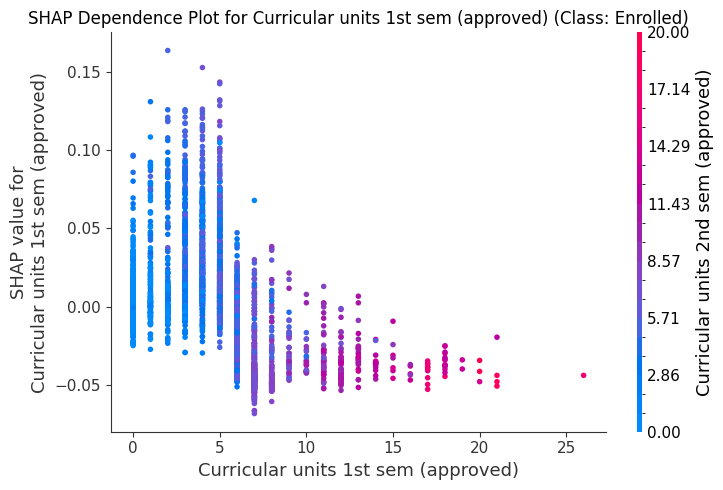

<Figure size 1000x600 with 0 Axes>

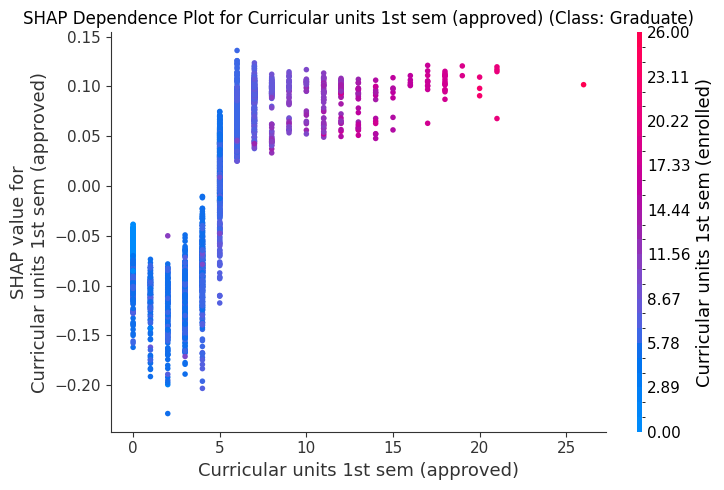

SHAP dependence plots generated.


In [ ]:
import matplotlib.pyplot as plt

# Select the top N features for dependence plots
n_dependence_features = 3
top_dependence_features = feature_importances['feature'].head(n_dependence_features).tolist()

print(f"Generating SHAP dependence plots for the top {n_dependence_features} features...")

# Iterate through each selected feature
for feature in top_dependence_features:
    # Get the index of the feature in X_explain's columns
    # feature_idx = X_explain.columns.get_loc(feature) # Not strictly needed for dependence_plot if 'feature' string is passed

    # Generate dependence plot for each class
    for i, class_name in enumerate(class_names):
        plt.figure(figsize=(10, 6))
        # shap_values is a list of arrays for multi-class, where each element is for a class.
        # So, shap_values[i] gives SHAP values for class 'i'
        shap.dependence_plot(
            ind=feature,
            shap_values=shap_values[:, :, i], # Select SHAP values for the current class (i)
            features=X_explain,
            # interaction_index=None, # Automatically finds best interaction feature
            # or specify an interaction feature if desired, e.g., interaction_index='Age at enrollment'
            show=False # Suppress auto-display to allow custom titles
        )
        plt.title(f'SHAP Dependence Plot for {feature} (Class: {class_name})')
        plt.tight_layout()
        plt.show()

print("SHAP dependence plots generated.")

## Generate Partial Dependence Plots (PDPs)


Generating Partial Dependence Plots for key numerical features...


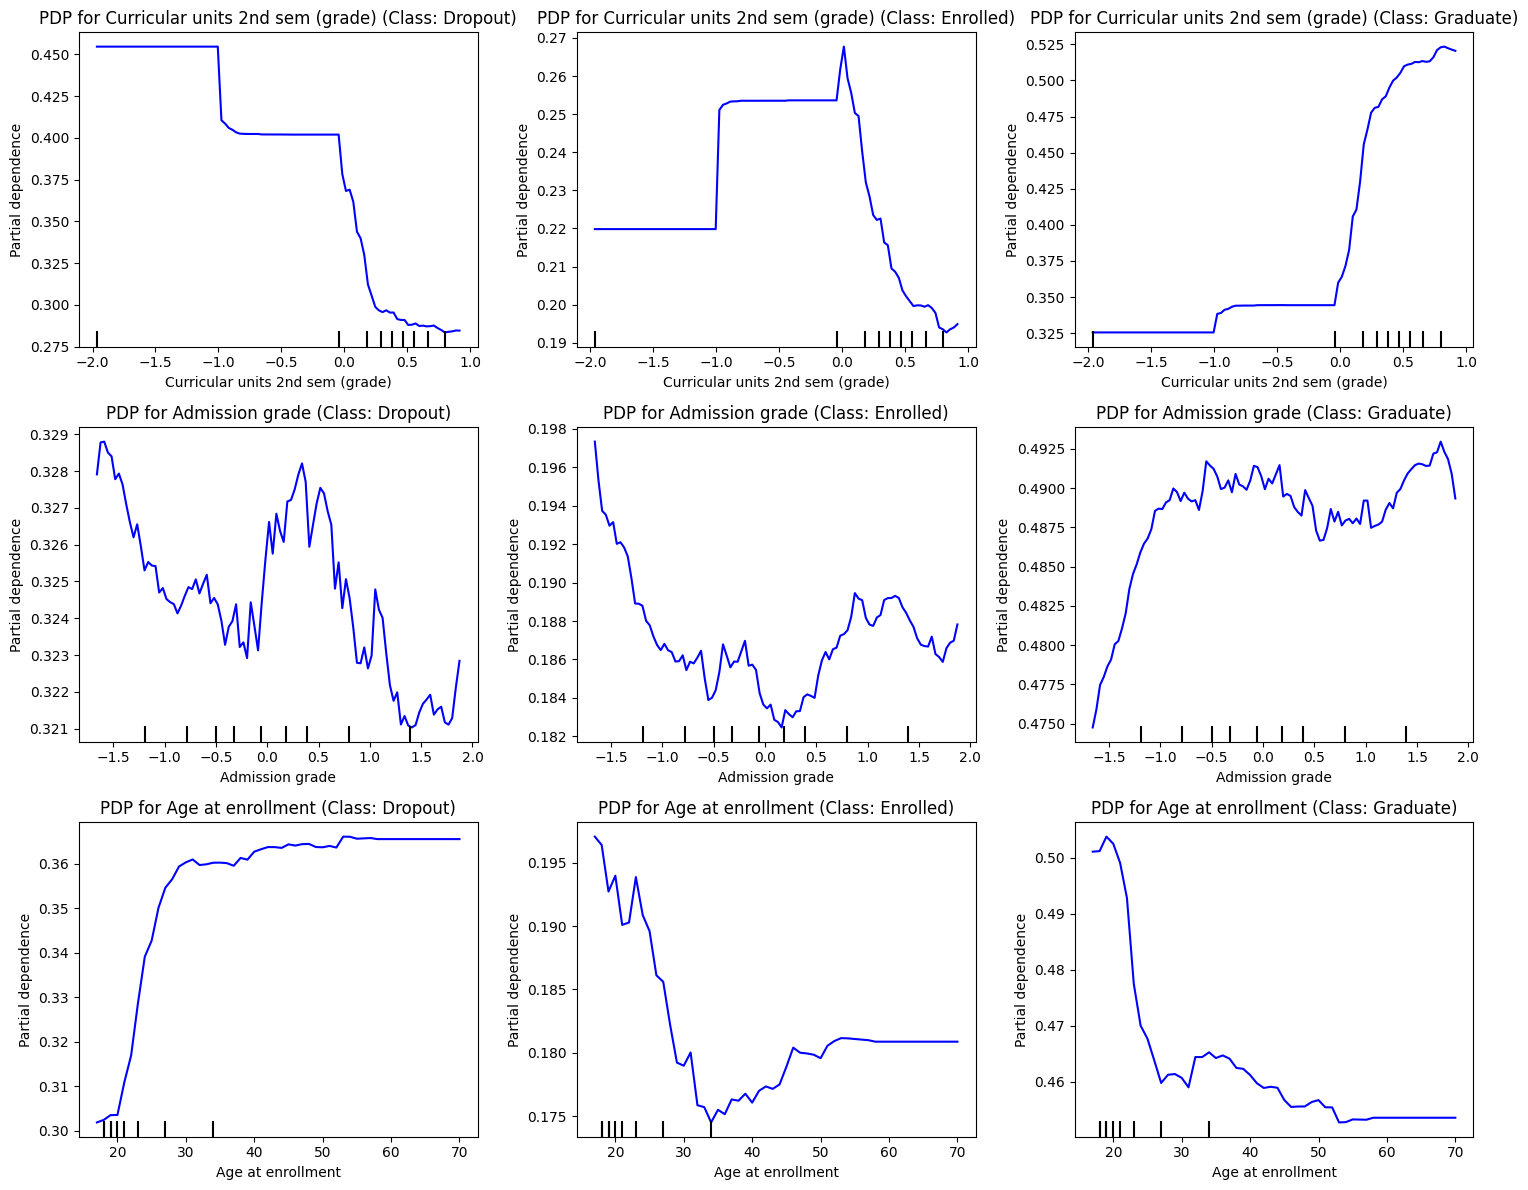

Partial Dependence Plots generated successfully.


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Ensure `best_random_forest_model` and `X_selected` (or `X_explain`) are available from previous steps
# Also ensure `class_names` and `le` are available.

print("Generating Partial Dependence Plots for key numerical features...")

# Define the key features for PDP as specified in the subtask
key_features_for_pdp = ['Curricular units 2nd sem (grade)', 'Admission grade', 'Age at enrollment']

# Prepare the data and model for PDP
model = best_random_forest_model
features = X_selected # Use X_selected which contains the top features from training

# Create a figure for all PDPs
n_features = len(key_features_for_pdp)
n_classes = len(class_names)

# Set up subplots dynamically
fig, axes = plt.subplots(n_features, n_classes, figsize=(5 * n_classes, 4 * n_features), squeeze=False)

for i, feature_name in enumerate(key_features_for_pdp):
    for j, class_label in enumerate(class_names):
        # PartialDependenceDisplay requires a feature to be specified by its name or index
        # For multi-class, it generates one plot per class automatically if target_class is not specified.
        # To get separate plots per class as per instruction, we specify target_class.

        # Create a single plot for the current feature and target class
        display = PartialDependenceDisplay.from_estimator(
            estimator=model,
            X=features,
            features=[feature_name],
            target=j, # Specify the target class (0, 1, 2 for 'Dropout', 'Enrolled', 'Graduate')
            ax=axes[i, j],
            line_kw={'color': 'blue'}
        )
        axes[i, j].set_title(f'PDP for {feature_name} (Class: {class_label})')
        axes[i, j].set_xlabel(feature_name)
        axes[i, j].set_ylabel('Partial Dependence')

plt.tight_layout()
plt.show()

print("Partial Dependence Plots generated successfully.")

## Generate Individual Conditional Expectation (ICE) Plots


Generating Individual Conditional Expectation (ICE) Plots for key numerical features...


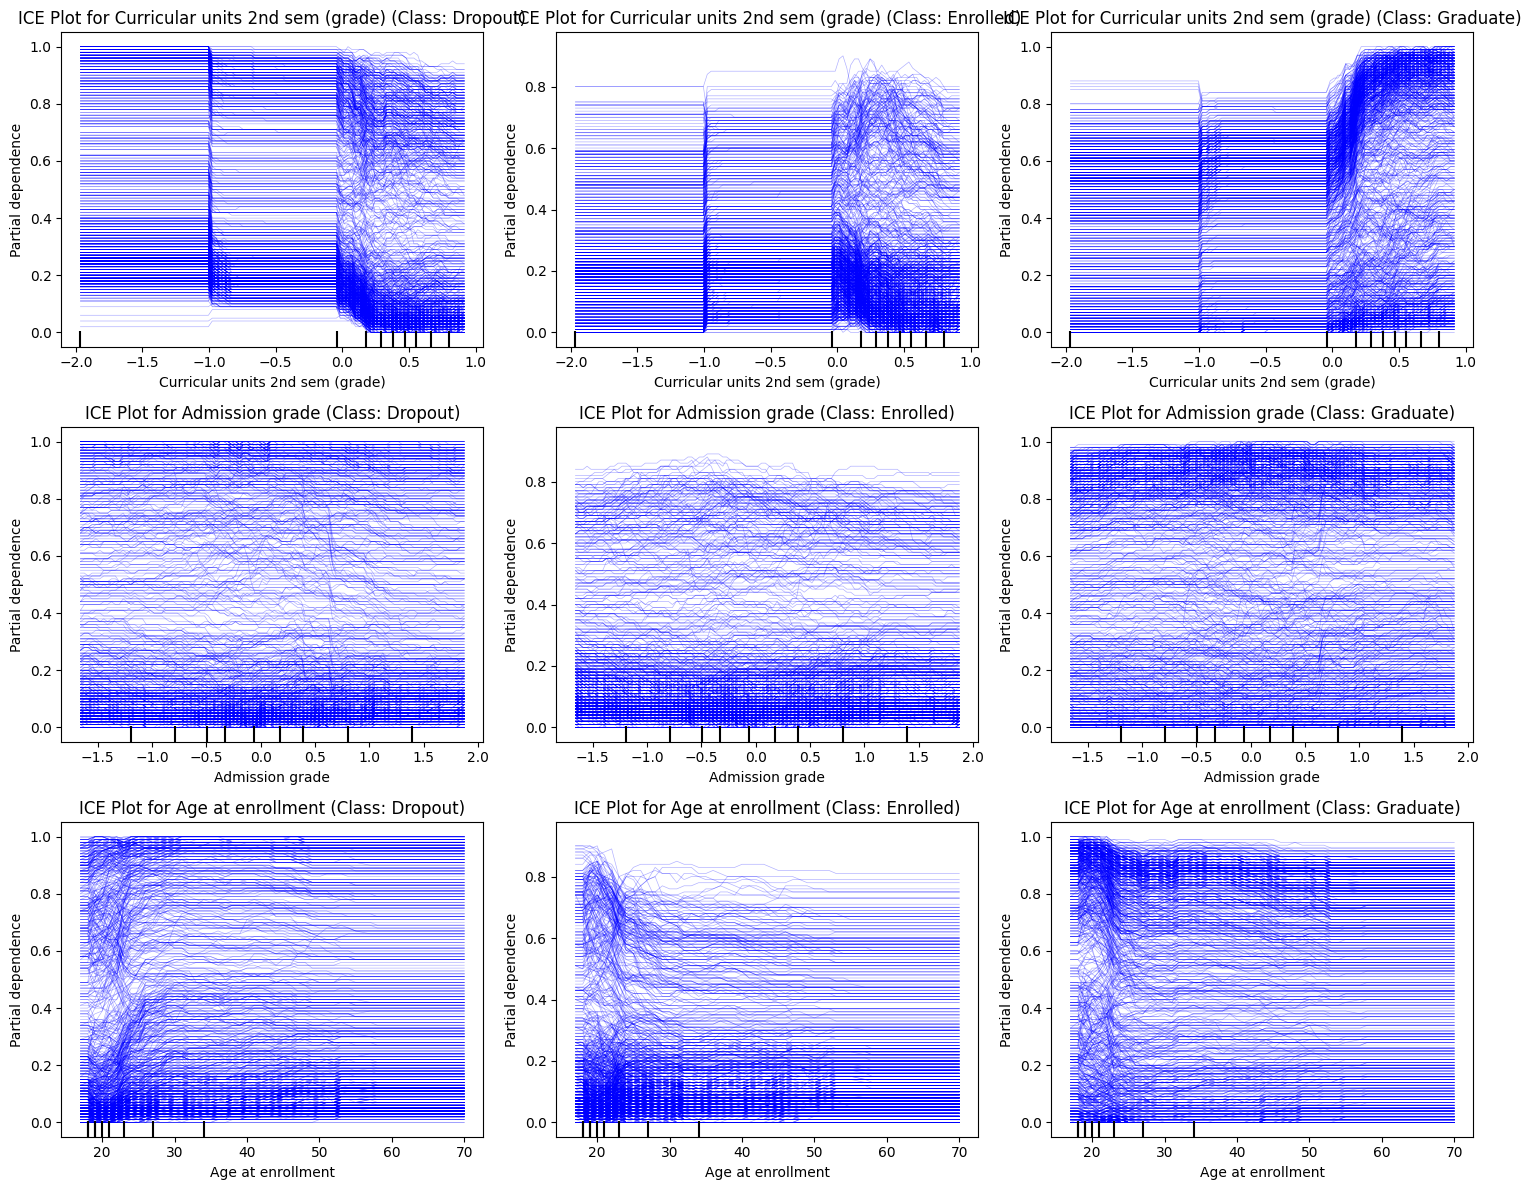

Individual Conditional Expectation (ICE) Plots generated successfully.


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Ensure `best_random_forest_model`, `X_selected` (or `X_explain`), and `class_names` are available

print("Generating Individual Conditional Expectation (ICE) Plots for key numerical features...")

# Define the key features for ICE as specified in the subtask
key_features_for_ice = ['Curricular units 2nd sem (grade)', 'Admission grade', 'Age at enrollment']

# Prepare the data and model for ICE
model = best_random_forest_model
features = X_selected # Use X_selected which contains the top features from training

# Create a figure for all ICE plots
n_features = len(key_features_for_ice)
n_classes = len(class_names)

# Set up subplots dynamically
fig, axes = plt.subplots(n_features, n_classes, figsize=(5 * n_classes, 4 * n_features), squeeze=False)

for i, feature_name in enumerate(key_features_for_ice):
    for j, class_label in enumerate(class_names):
        # Create a single plot for the current feature and target class
        PartialDependenceDisplay.from_estimator(
            estimator=model,
            X=features,
            features=[feature_name],
            target=j, # Specify the target class (0, 1, 2 for 'Dropout', 'Enrolled', 'Graduate')
            kind='individual', # This specifies that we want ICE plots
            ax=axes[i, j],
            line_kw={'color': 'blue', 'alpha': 0.3} # Alpha for individual lines
        )
        axes[i, j].set_title(f'ICE Plot for {feature_name} (Class: {class_label})')
        axes[i, j].set_xlabel(feature_name)
        axes[i, j].set_ylabel('Individual Prediction')

plt.tight_layout()
plt.show()

print("Individual Conditional Expectation (ICE) Plots generated successfully.")

In [ ]:
pip install lime

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np # Import numpy for np.where

# Initialize LimeTabularExplainer
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=class_names,
    mode='classification'
)

print("LimeTabularExplainer initialized.")

# Select diverse instances for explanation
# Find an index for each class from the X_explain set using np.where
# le.transform(['Class Name'])[0] returns the numerical representation of the class
instance_dropout_idx = np.where(y_explain == le.transform(['Dropout'])[0])[0][0]
instance_enrolled_idx = np.where(y_explain == le.transform(['Enrolled'])[0])[0][0]
instance_graduate_idx = np.where(y_explain == le.transform(['Graduate'])[0])[0][0]

# Select the instances from X_explain using iloc since X_explain is a DataFrame
instance_dropout = X_explain.iloc[instance_dropout_idx]
instance_enrolled = X_explain.iloc[instance_enrolled_idx]
instance_graduate = X_explain.iloc[instance_graduate_idx]

print("Selected instances for explanation:")
print(f"  - Dropout instance shape: {instance_dropout.shape}")
print(f"  - Enrolled instance shape: {instance_enrolled.shape}")
print(f"  - Graduate instance shape: {instance_graduate.shape}")

print("Selected specific instances from each class for LIME explanations.")

LimeTabularExplainer initialized.
Selected instances for explanation:
  - Dropout instance shape: (50,)
  - Enrolled instance shape: (50,)
  - Graduate instance shape: (50,)
Selected specific instances from each class for LIME explanations.


In [ ]:
import joblib # Import joblib to load the model

# Load the best_random_forest_model if not already in memory
# This ensures the predict_proba method is available to LIME
best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Generate explanation for the Dropout instance
explanation_dropout = explainer_lime.explain_instance(
    data_row=instance_dropout.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_dropout = 'lime_explanation_dropout.html'
explanation_dropout.save_to_file(filename_dropout)

print(f"LIME explanation for 'Dropout' instance saved to {filename_dropout}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME explanation for 'Dropout' instance saved to lime_explanation_dropout.html


In [ ]:
import joblib # Import joblib to load the model

# Load the best_random_forest_model if not already in memory
# This ensures the predict_proba method is available to LIME
best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Generate explanation for the Dropout instance
explanation_dropout = explainer_lime.explain_instance(
    data_row=instance_dropout.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_dropout = 'lime_explanation_dropout.html'
explanation_dropout.save_to_file(filename_dropout)

print(f"LIME explanation for 'Dropout' instance saved to {filename_dropout}")

# Generate explanation for the Enrolled instance
explanation_enrolled = explainer_lime.explain_instance(
    data_row=instance_enrolled.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_enrolled = 'lime_explanation_enrolled.html'
explanation_enrolled.save_to_file(filename_enrolled)

print(f"LIME explanation for 'Enrolled' instance saved to {filename_enrolled}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME explanation for 'Dropout' instance saved to lime_explanation_dropout.html
LIME explanation for 'Enrolled' instance saved to lime_explanation_enrolled.html


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib # Import joblib to load the model

# Load the best_random_forest_model if not already in memory
best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Generate explanation for the Graduate instance
explanation_graduate = explainer_lime.explain_instance(
    data_row=instance_graduate.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_graduate = 'lime_explanation_graduate.html'
explanation_graduate.save_to_file(filename_graduate)

print(f"LIME explanation for 'Graduate' instance saved to {filename_graduate}")

LIME explanation for 'Graduate' instance saved to lime_explanation_graduate.html


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib # Import joblib to load the model

# Load the best_random_forest_model if not already in memory
# This ensures the predict_proba method is available to LIME
best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Generate explanation for the Graduate instance
explanation_graduate = explainer_lime.explain_instance(
    data_row=instance_graduate.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_graduate = 'lime_explanation_graduate.html'
explanation_graduate.save_to_file(filename_graduate)

print(f"LIME explanation for 'Graduate' instance saved to {filename_graduate}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME explanation for 'Graduate' instance saved to lime_explanation_graduate.html
